In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import argparse
import pandas as pd
import numpy as np
import tfsplt_future_past_utils as pu

## Configuration

In [3]:
# define parameters
class Args(argparse.Namespace):

    rois = ["IFG","MTG", "STG","preCG","postCG", "rostralmiddlefrontal",
        "superiorfrontal", "supramarginal", "ITG", "TP", "fusiform", "All"]
    # rois = ["IFG","STG","preCG","postCG","TP","dSM","mSM","vSM", "All"]    
    
    # NOTE: lines must match the label3 values in the data (standardized without _banded_ prefix)
    lines = ["joint", "word", "sentence", "sentence2"] # line id
    # colors = ["green", "grey", "orange", "red", "black", "purple"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    legends = ["joint", "word", "future", "past"]

    lags = {
            "lags_all": np.arange(-2000, 2001, 50),
            "lags_plt": np.arange(-2000, 2001, 50), # selected subset
            "lag_ticks": np.arange(-2000, 2001, 500), # this and next one need to have same number of elements
            "lag_tick_labels": np.arange(-2, 2.001, 0.5), # this and previous one need to have same number of elements
        }
    res_dir = '/scratch/gpfs/gidon/247-plotting/results/figures'

## Load Data

### Original

In [3]:
args = Args()
all_elecs = pd.read_csv("/scratch/gpfs/HASSON/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")
thresh_single = None # for selecting electrodes by all(dfs)
res_d = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"

# Get shared indices for different lag ranges
shared_ind_l, shared_ind_s = pu.get_shared_indices(
    lags_large=np.arange(-60000,60001,50),
    lags_small=np.arange(-30000, 30001, 50)
)

# Load context16 (original no rephrase)
context16_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv", 
    thresh_single
)
context16_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv", 
    thresh_single
)
print("shape of context_16_c before selecting shared columns:", context16_c.shape)
context16_c = pu.select_shared_and_last_columns(context16_c, shared_ind_l)
context16_p = pu.select_shared_and_last_columns(context16_p, shared_ind_l)

# Load context4
context4_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context4_comp.csv", 
    thresh_single
)
context4_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context4_prod.csv", 
    thresh_single
)
print("shape of context_4_c before selecting shared columns:", context4_c.shape)
context4_c = pu.select_shared_and_last_columns(context4_c, shared_ind_s)
context4_p = pu.select_shared_and_last_columns(context4_p, shared_ind_s)

# Load context64
context64_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context64_comp.csv", 
    thresh_single
)
context64_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context64_prod.csv", 
    thresh_single
)
context64_c = pu.select_shared_and_last_columns(context64_c, shared_ind_s)
context64_p = pu.select_shared_and_last_columns(context64_p, shared_ind_s)

context2_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context2_comp.csv", 
    thresh_single
)
context2_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context2_prod.csv", 
    thresh_single   
)
context2_c = pu.select_shared_and_last_columns(context2_c, shared_ind_s)
context2_p = pu.select_shared_and_last_columns(context2_p, shared_ind_s)

context8_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context8_comp.csv", 
    thresh_single
)
context8_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context8_prod.csv", 
    thresh_single
)
context8_c = pu.select_shared_and_last_columns(context8_c, shared_ind_s)
context8_p = pu.select_shared_and_last_columns(context8_p, shared_ind_s)

# Compile dfs and titles
df_list_c = [context2_c,  context4_c, context8_c, context16_c, context64_c]
df_list_p = [context2_p,  context4_p, context8_p, context16_p, context64_p]
titles = ["Context 2", "Context 4", "Context 8", "Context 16", "Context 64"]

# Process shared electrodes across datasets
shared_electrodes_c, filtered_dfs_c, roi_results_c = pu.process_shared_electrodes_roi(
    df_list_c,
    args.rois,
    OR_thresh=0.1
)
shared_electrodes_p, filtered_dfs_p, roi_results_p = pu.process_shared_electrodes_roi(
    df_list_p,
    args.rois,
    OR_thresh=0.1
)

print(f"Comprehension: {len(shared_electrodes_c)} shared electrodes")
print(f"Production: {len(shared_electrodes_p)} shared electrodes")

shape of context_16_c before selecting shared columns: (2644, 2406)
shape of context_4_c before selecting shared columns: (2644, 1206)
Comprehension: 345 shared electrodes
Production: 335 shared electrodes


### Rephrase



In [5]:
args = Args()
all_elecs = pd.read_csv("/scratch/gpfs/HASSON/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")
thresh_single = None 
res_d = "/scratch/gpfs/HASSON/gidon/247-encoding-dev/results/tfs"
res_d_itamar = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"

# For plotting, we want to align all results to the same lag window (ms).
# This avoids fragile iloc-based indexing when different result files have different lag grids.

shared_ind_l, shared_ind_m, shared_ind_s  = pu.get_shared_indices(np.arange(-120000, 120001, 50), np.arange(-60000,60001,50), np.arange(-2000, 2001, 25))
LAG_MIN, LAG_MAX = -2000, 2000

paraphrase4_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0004_comp.csv", thresh_single)
paraphrase4_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0004_prod.csv", thresh_single)
print(f"Loaded paraphrase sentences: {len(paraphrase4_c)} comprehension, {len(paraphrase4_p)} production electrodes")
paraphrase4_c = pu.select_lag_range_and_last_columns(paraphrase4_c, LAG_MIN, LAG_MAX)
paraphrase4_p = pu.select_lag_range_and_last_columns(paraphrase4_p, LAG_MIN, LAG_MAX)
paraphrase4_c['label3'] = paraphrase4_c['label3'].str.replace('_banded_', '', regex=False)
paraphrase4_p['label3'] = paraphrase4_p['label3'].str.replace('_banded_', '', regex=False)

paraphrase8_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_comp.csv", thresh_single)
paraphrase8_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_prod.csv", thresh_single)
print(f"Loaded paraphrase sentences: {len(paraphrase8_c)} comprehension, {len(paraphrase8_p)} production electrodes")
paraphrase8_c = pu.select_lag_range_and_last_columns(paraphrase8_c, LAG_MIN, LAG_MAX)
paraphrase8_p = pu.select_lag_range_and_last_columns(paraphrase8_p, LAG_MIN, LAG_MAX)
paraphrase8_c['label3'] = paraphrase8_c['label3'].str.replace('_banded_', '', regex=False)
paraphrase8_p['label3'] = paraphrase8_p['label3'].str.replace('_banded_', '', regex=False)

paraphrase_c16 = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_comp.csv", thresh_single)
paraphrase_p16 = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_prod.csv", thresh_single)
print(f"Loaded paraphrase sentences: {len(paraphrase_c16)} comprehension, {len(paraphrase_p16)} production electrodes")
paraphrase_c16 = pu.select_shared_and_last_columns(paraphrase_c16, shared_ind_s)
paraphrase_p16 = pu.select_shared_and_last_columns(paraphrase_p16, shared_ind_s)  
paraphrase_c16['label3'] = paraphrase_c16['label3'].str.replace('_banded_', '', regex=False)
paraphrase_p16['label3'] = paraphrase_p16['label3'].str.replace('_banded_', '', regex=False)
df_list_c = [paraphrase4_c, paraphrase8_c, paraphrase_c16]
df_list_p = [paraphrase4_p, paraphrase8_p, paraphrase_p16]
titles = ["paraphrase 4", "paraphrase 8", "paraphrase 16"]

Loaded paraphrase sentences: 2640 comprehension, 2640 production electrodes
Loaded paraphrase sentences: 2147 comprehension, 2132 production electrodes
Loaded paraphrase sentences: 2631 comprehension, 2635 production electrodes


### Random content

In [11]:
args = Args()
all_elecs = pd.read_csv("/scratch/gpfs/HASSON/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")
thresh_single = None 
res_d = "/scratch/gpfs/HASSON/gidon/247-encoding-dev/results/tfs"
res_d_itamar = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"

# For plotting, we want to align all results to the same lag window (ms).
# This avoids fragile iloc-based indexing when different result files have different lag grids.

shared_ind_l, shared_ind_m, shared_ind_s  = pu.get_shared_indices(np.arange(-120000, 120001, 50), np.arange(-60000,60001,50), np.arange(-2000, 2001, 25))
LAG_MIN, LAG_MAX = -2000, 2000

random_content_words4_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0004_comp.csv", thresh_single)
random_content_words4_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0004_prod.csv", thresh_single)
print(f"Loaded random content words sentences: {len(random_content_words4_c)} comprehension, {len(random_content_words4_p)} production electrodes")
random_content_words4_c = pu.select_lag_range_and_last_columns(random_content_words4_c, LAG_MIN, LAG_MAX)
random_content_words4_p = pu.select_lag_range_and_last_columns(random_content_words4_p, LAG_MIN, LAG_MAX)
random_content_words4_c['label3'] = random_content_words4_c['label3'].str.replace('_banded_', '', regex=False)
random_content_words4_p['label3'] = random_content_words4_p['label3'].str.replace('_banded_', '', regex=False)

random_content_words8_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_comp.csv", thresh_single)
random_content_words8_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_prod.csv", thresh_single)
print(f"Loaded random content words sentences: {len(random_content_words8_c)} comprehension, {len(random_content_words8_p)} production electrodes")
random_content_words8_c = pu.select_lag_range_and_last_columns(random_content_words8_c, LAG_MIN, LAG_MAX)
random_content_words8_p = pu.select_lag_range_and_last_columns(random_content_words8_p, LAG_MIN, LAG_MAX)
random_content_words8_c['label3'] = random_content_words8_c['label3'].str.replace('_banded_', '', regex=False)
random_content_words8_p['label3'] = random_content_words8_p['label3'].str.replace('_banded_', '', regex=False)
random_content_words_c16 = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_comp.csv", thresh_single)
random_content_words_p16 = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_prod.csv", thresh_single)
print(f"Loaded random content words sentences: {len(random_content_words_c16)} comprehension, {len(random_content_words_p16)} production electrodes")
random_content_words_c16 = pu.select_shared_and_last_columns(random_content_words_c16, shared_ind_s)
random_content_words_p16 = pu.select_shared_and_last_columns(random_content_words_p16, shared_ind_s)  
random_content_words_c16['label3'] = random_content_words_c16['label3'].str.replace('_banded_', '', regex=False)
random_content_words_p16['label3'] = random_content_words_p16['label3'].str.replace('_banded_', '', regex=False)


df_list_c = [random_content_words4_c, random_content_words8_c, random_content_words_c16]
df_list_p = [random_content_words4_p, random_content_words8_p, random_content_words_p16]
titles = ["random content words 4", "random content words 8", "random content words 16"]

Loaded random content words sentences: 2636 comprehension, 2580 production electrodes
Loaded random content words sentences: 2640 comprehension, 2636 production electrodes
Loaded random content words sentences: 2644 comprehension, 2624 production electrodes


In [12]:
# Process shared electrodes across datasets
shared_electrodes_c, filtered_dfs_c, roi_results_c = pu.process_shared_electrodes_roi(
    df_list_c,
    args.rois,
    OR_thresh=0.1
)
shared_electrodes_p, filtered_dfs_p, roi_results_p = pu.process_shared_electrodes_roi(
    df_list_p,
    args.rois,
    OR_thresh=0.1
)

print(f"Comprehension: {len(shared_electrodes_c)} shared electrodes")
print(f"Production: {len(shared_electrodes_p)} shared electrodes")

Comprehension: 267 shared electrodes
Production: 272 shared electrodes


## Plot Comprehension ROIs

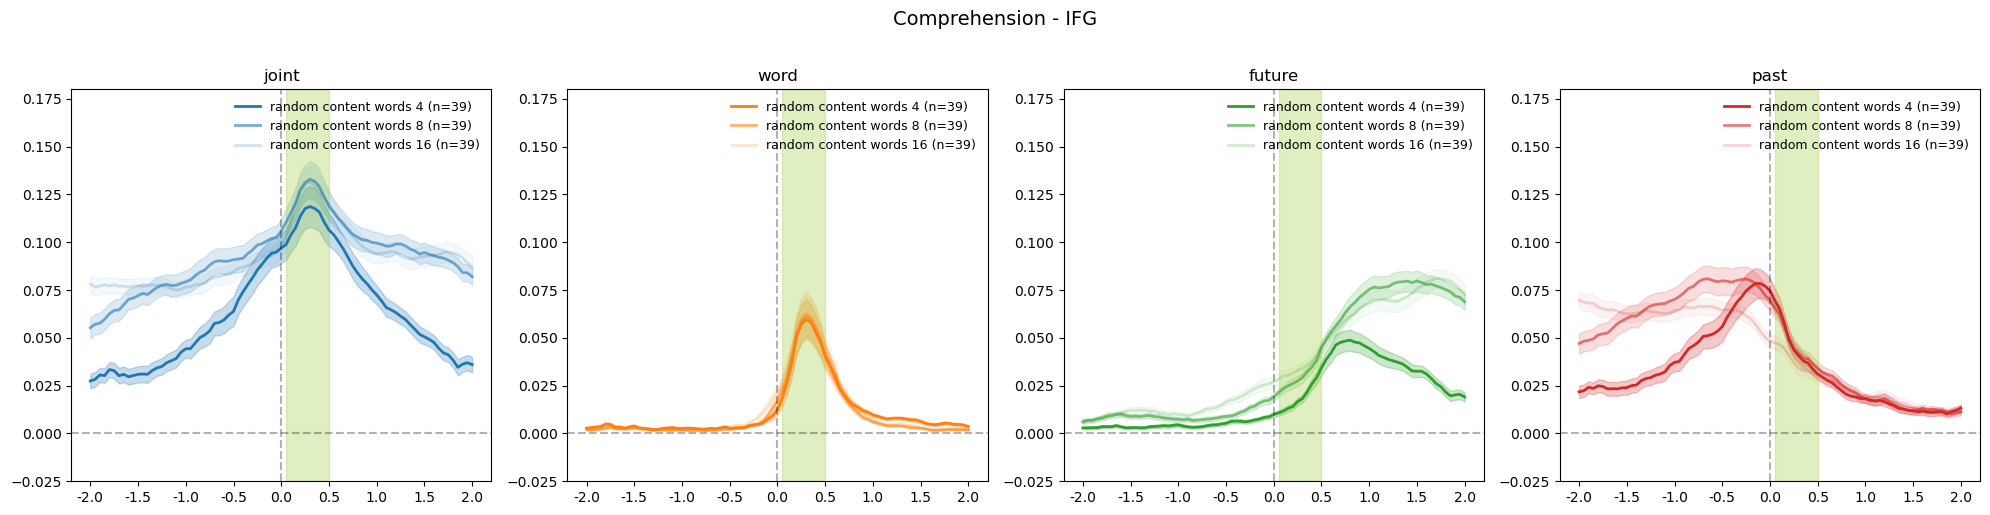

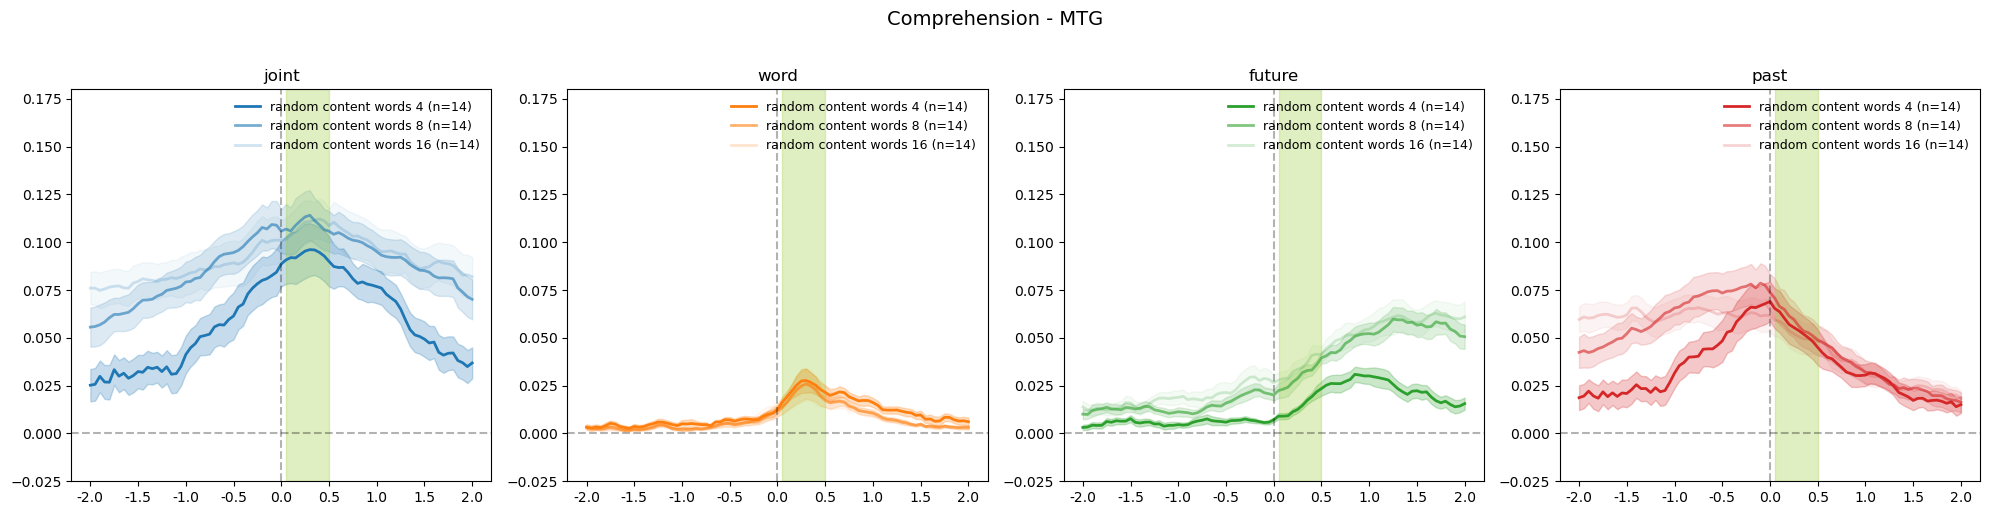

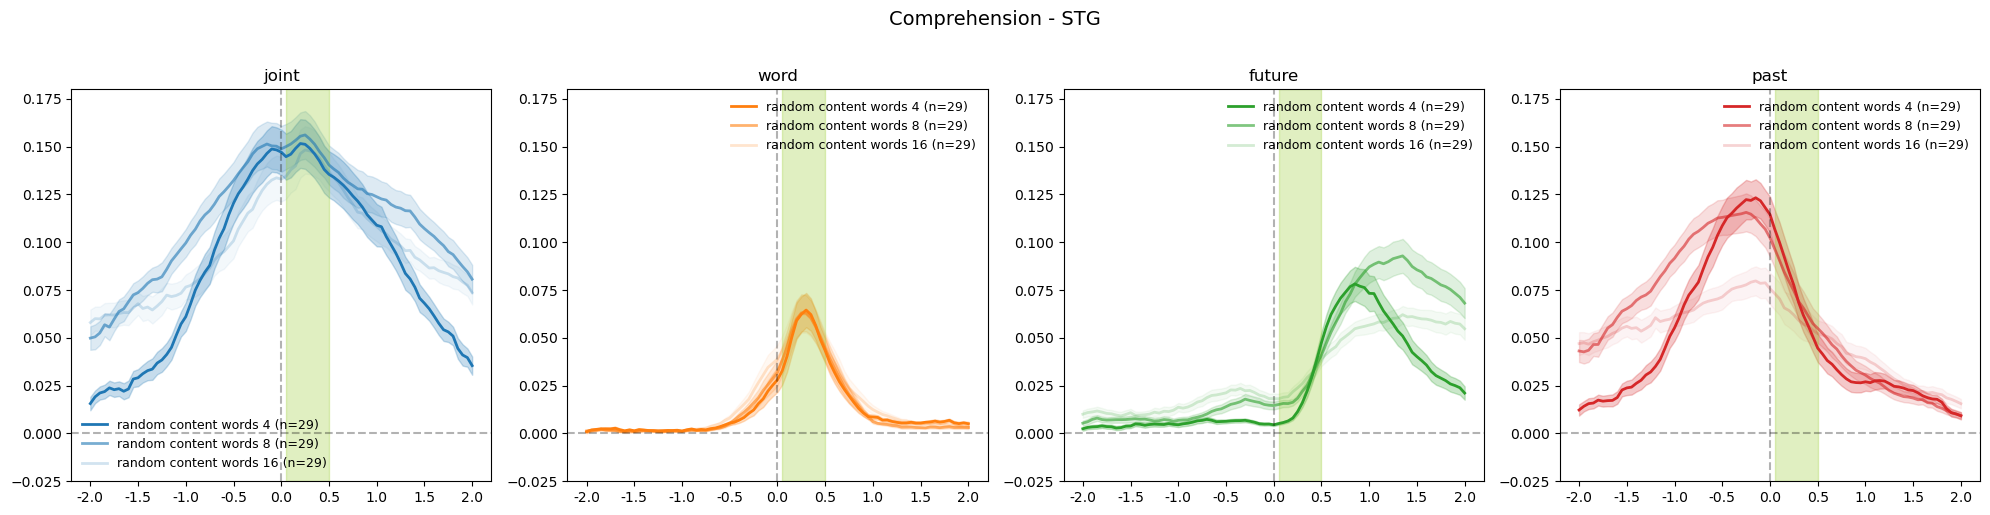

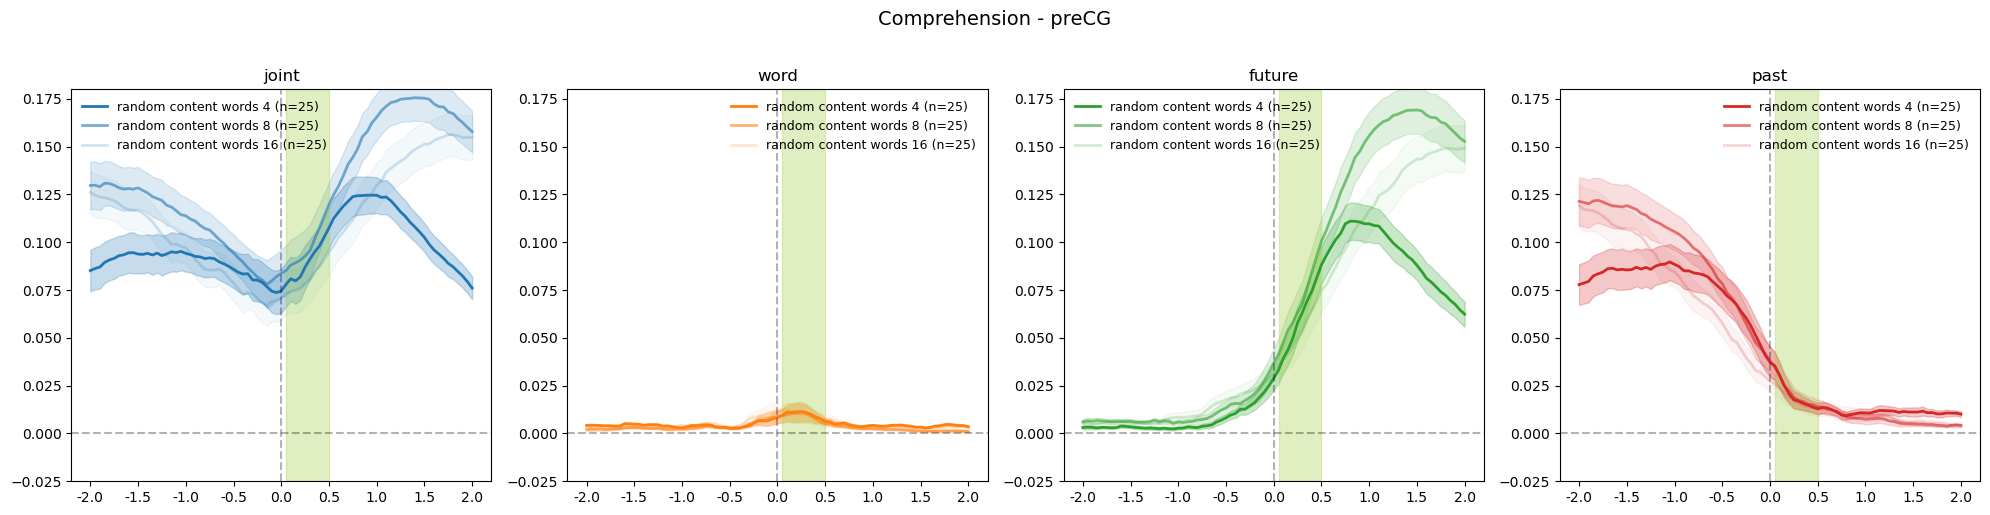

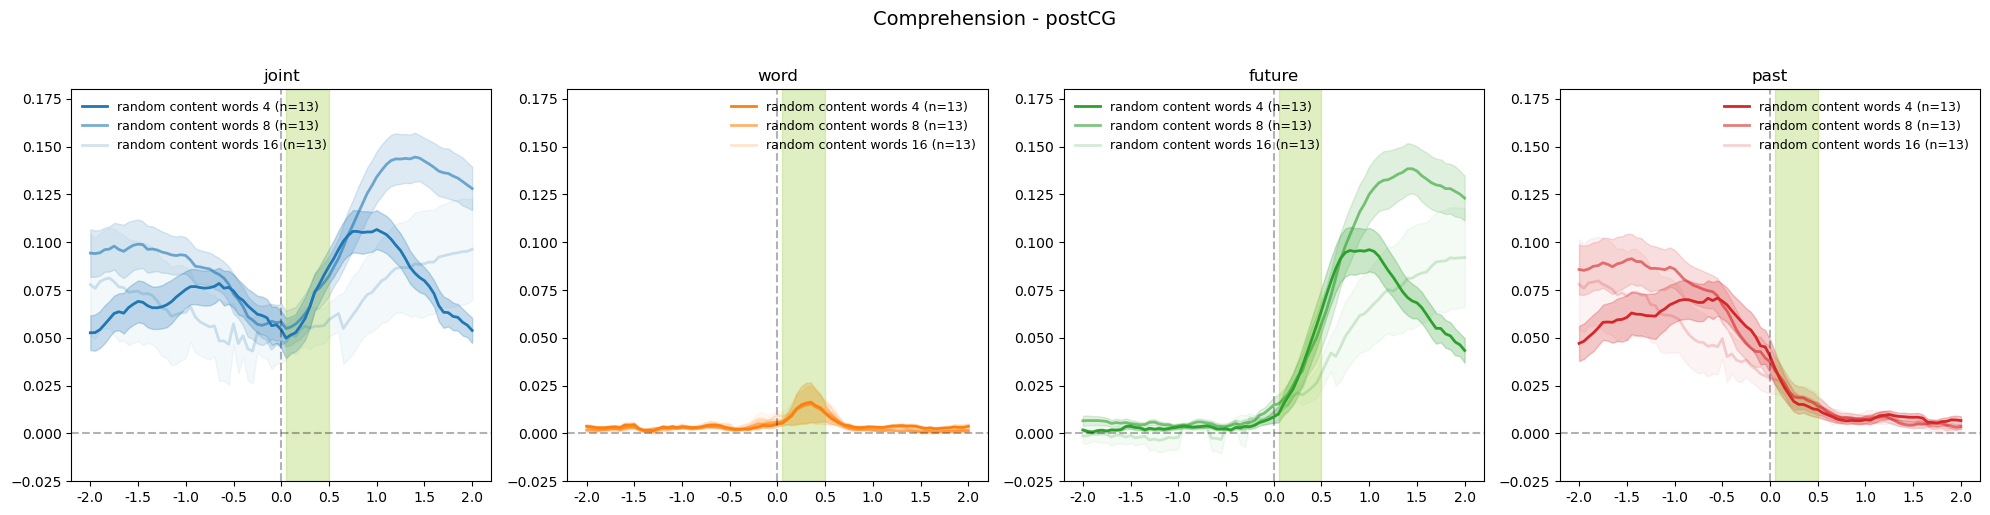

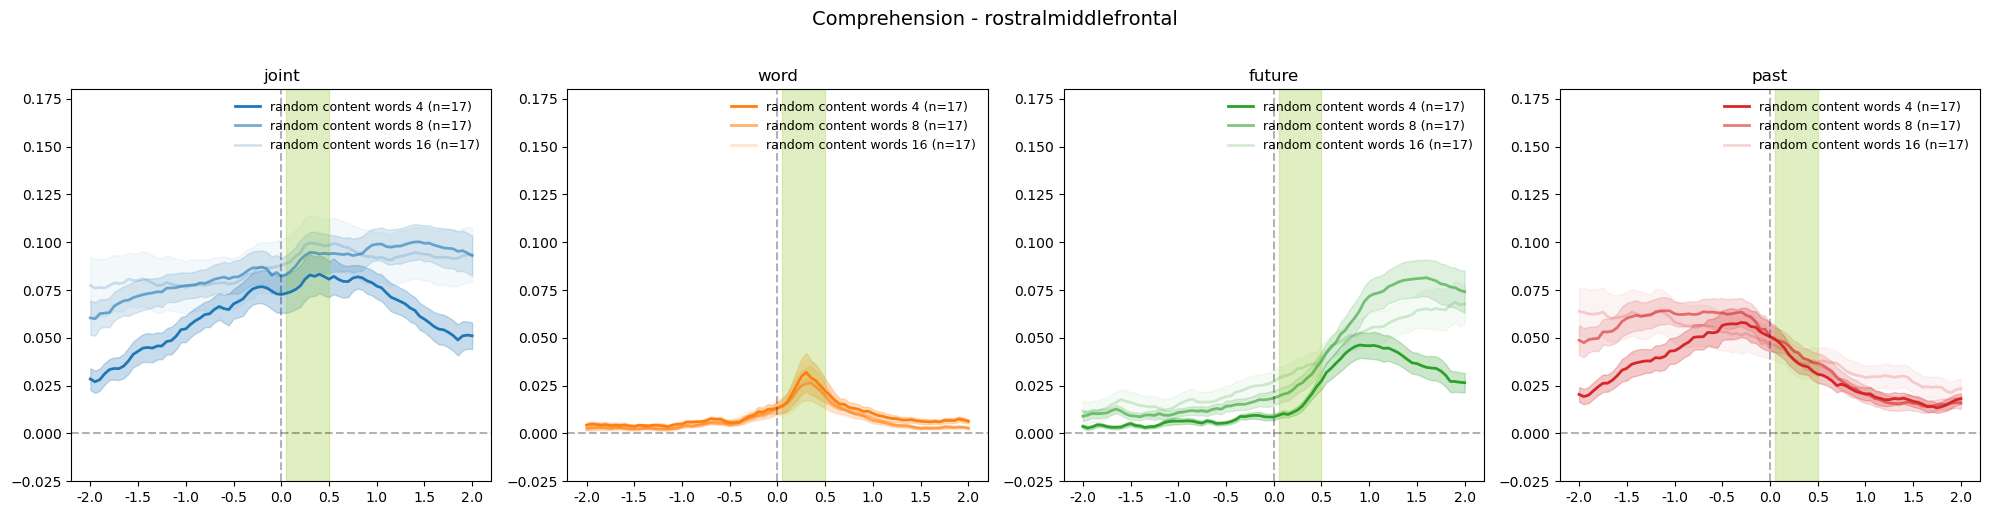

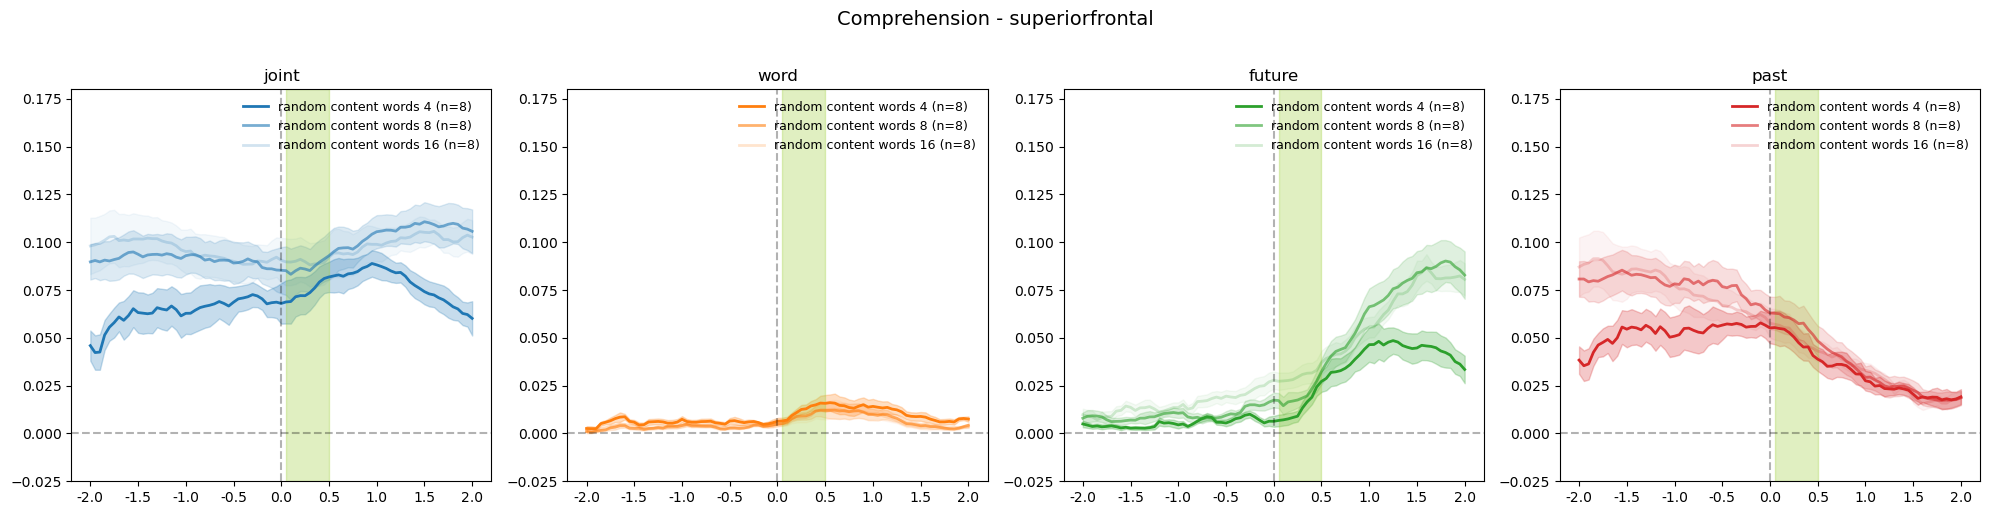

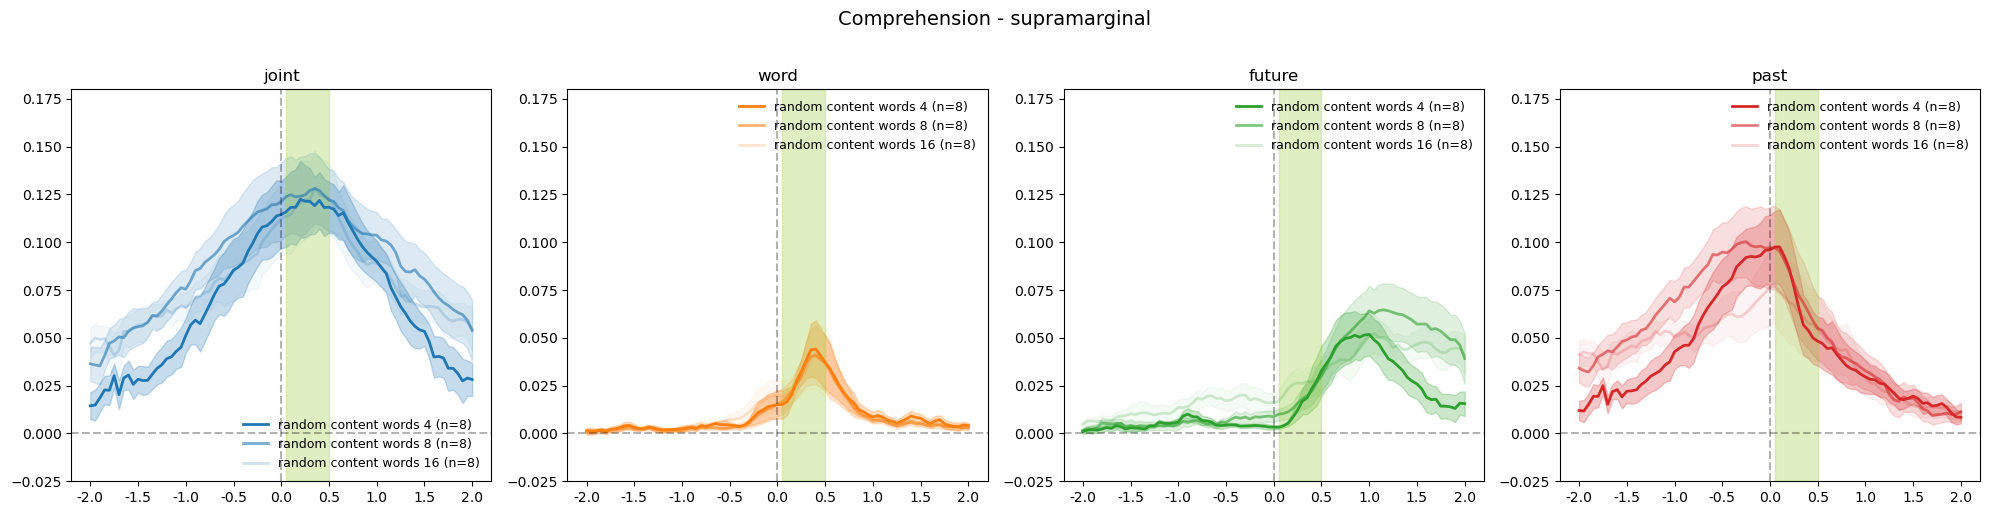

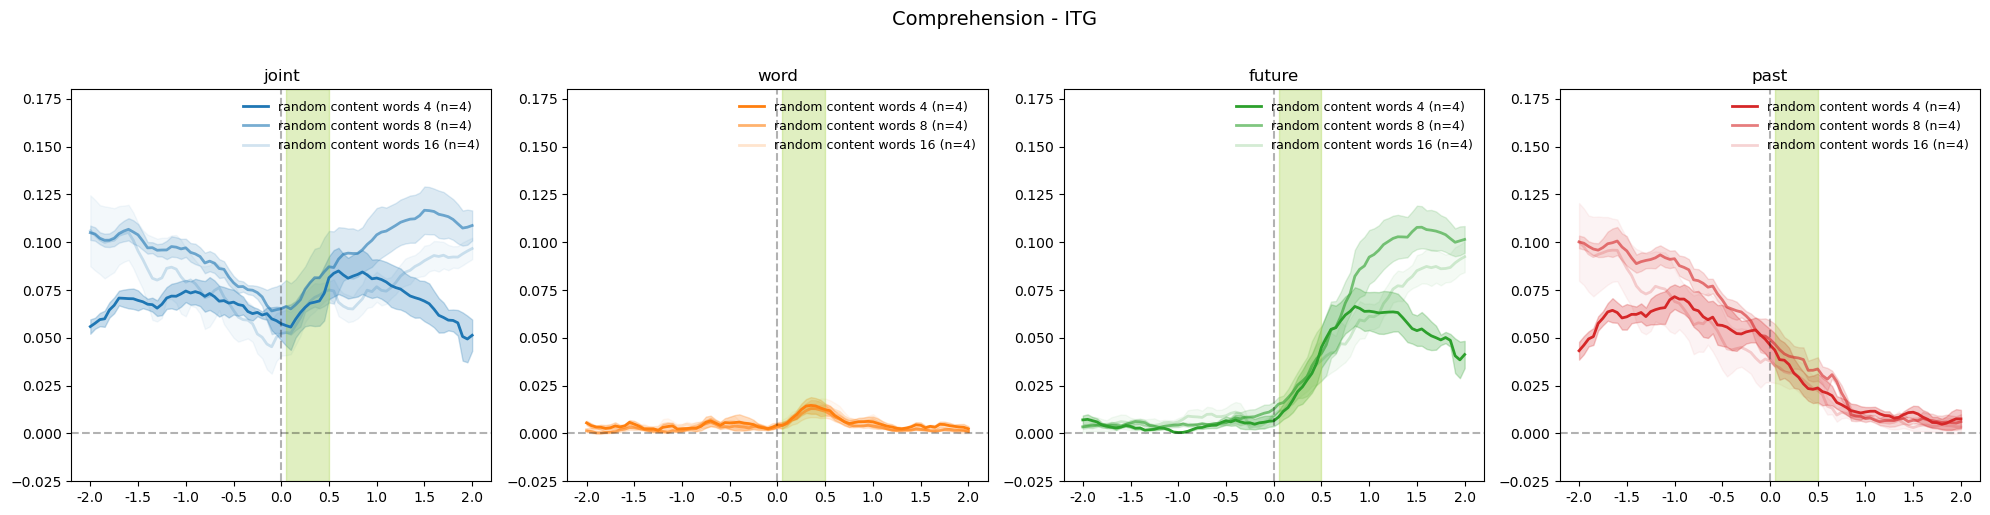

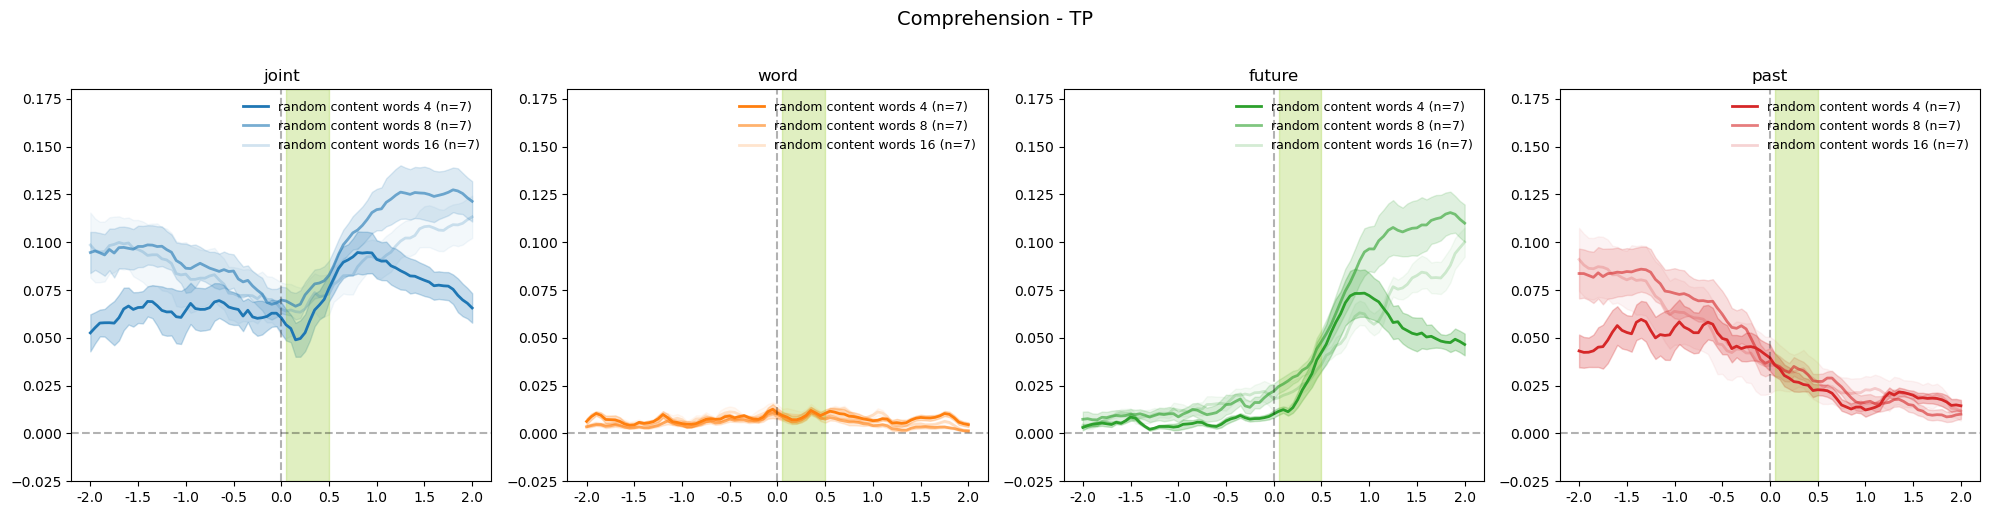

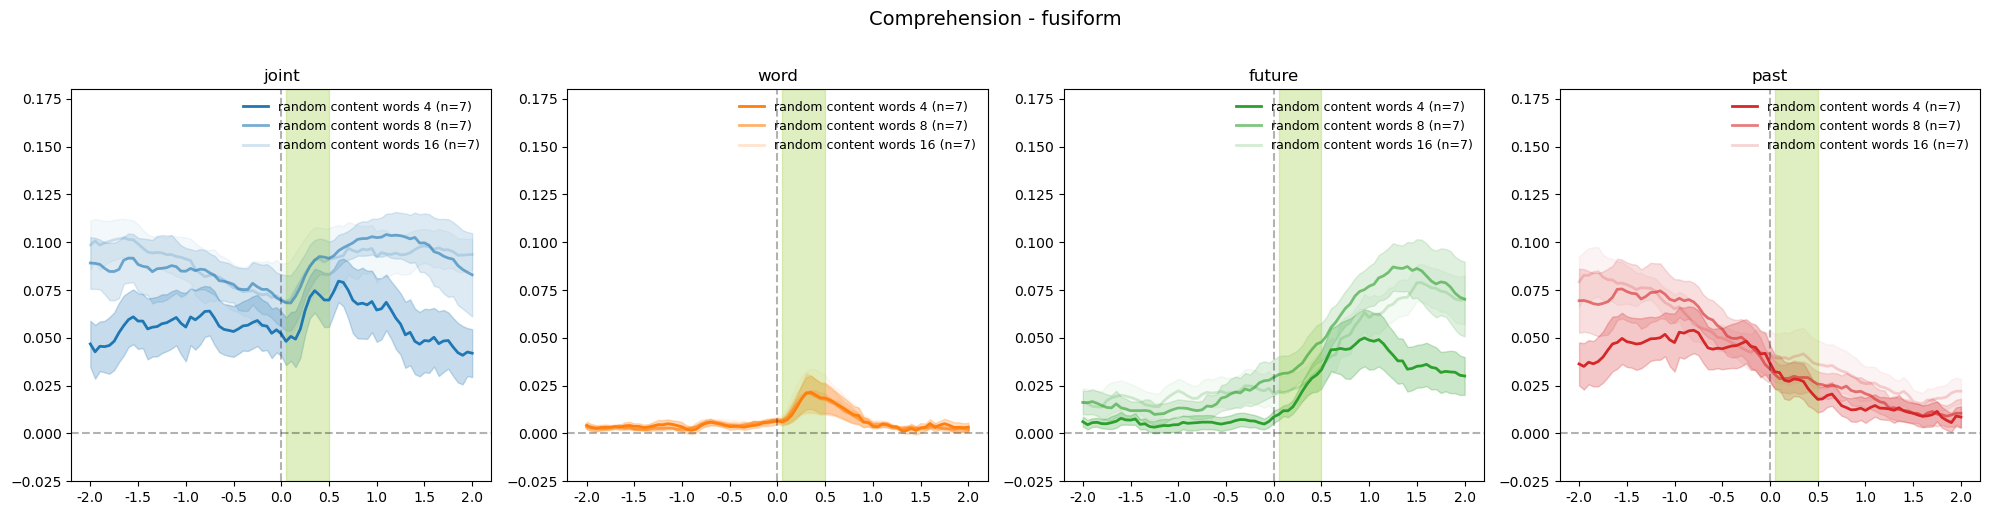

In [13]:
# Process and plot for comprehension DataFrames
args.lags = {
        "lags_all": np.arange(-2000, 2001, 50),
        "lags_plt": np.arange(-2000, 2001, 50), # selected subset
        "lag_ticks": np.arange(-2000, 2001, 500), # this and next one need to have same number of elements
        "lag_tick_labels": np.arange(-2, 2.001, 0.5), # this and previous one need to have same number of elements
    }

rois_to_plot_c = []
for roi in args.rois:
    key = (0, 'joint', roi)
    df = roi_results_c.get(key)
    if df is not None and df.shape[0] > 2:
        rois_to_plot_c.append(roi)

for roi in rois_to_plot_c:
    # Count electrodes
    n_elecs_c = next(
        (len(df) for key, df in roi_results_c.items() 
         if key[2] == roi and isinstance(df, pd.DataFrame) and not df.empty), 
        0
    )
    
    if n_elecs_c < 3:
        continue
    
    pu.plot_all_lines_across_datasets(
        args, 
        roi_results_c, 
        roi, 
        mode="comp", 
        ymax=0.18, 
        save=False, 
        titles=titles
    )

## Plot Production ROIs

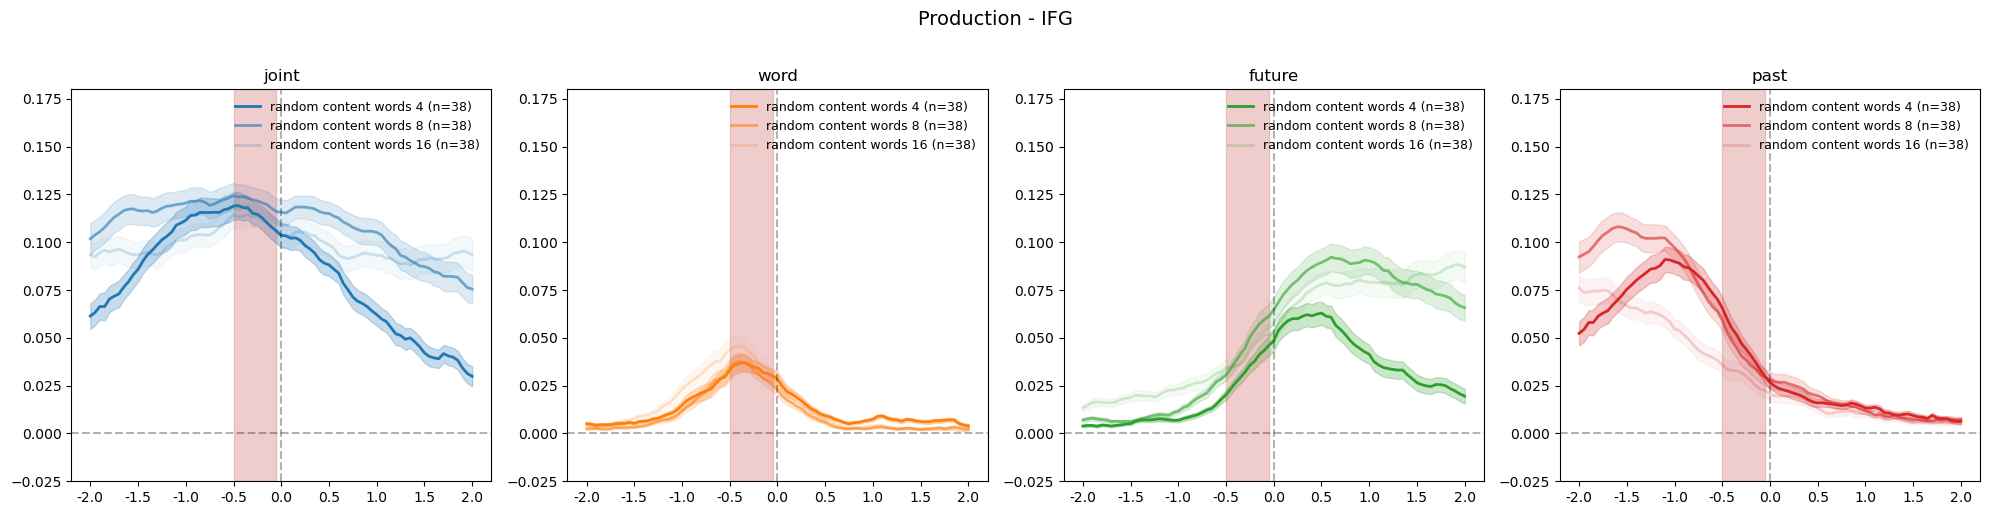

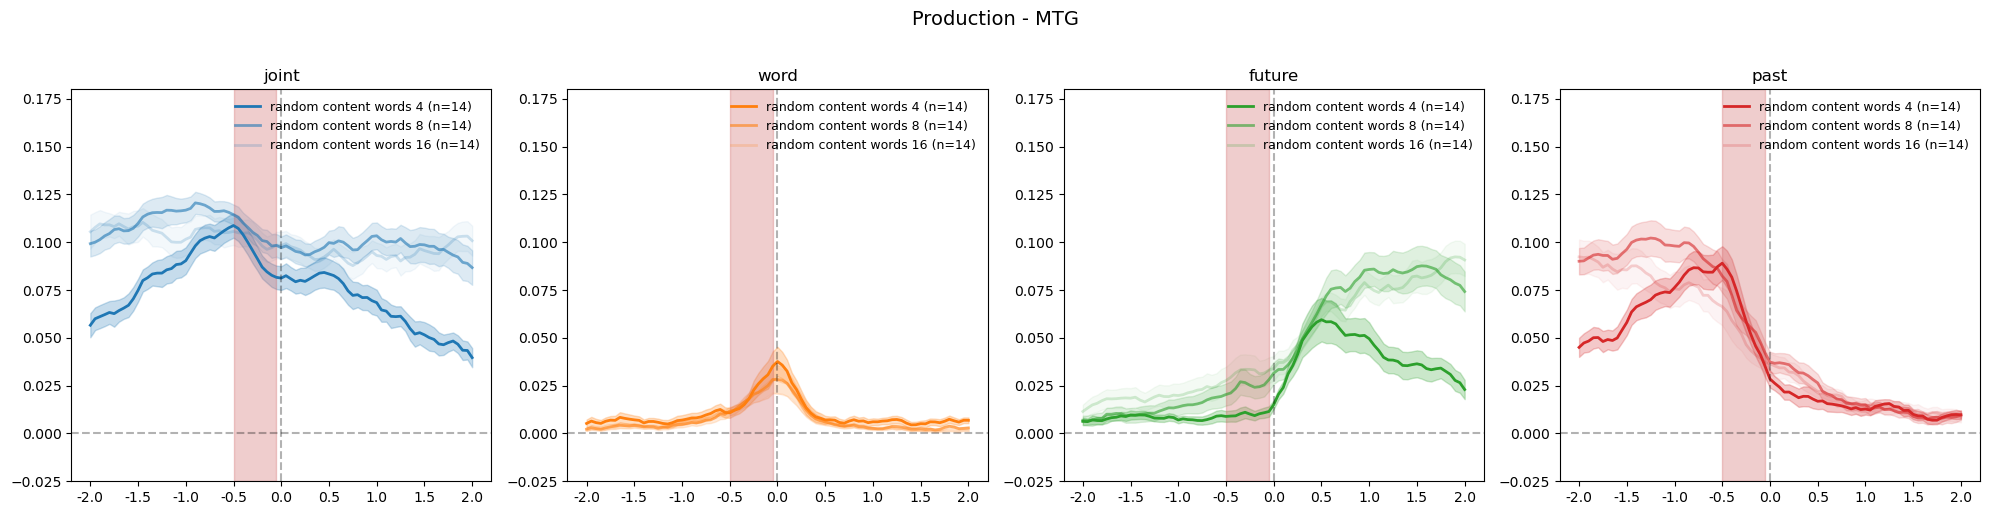

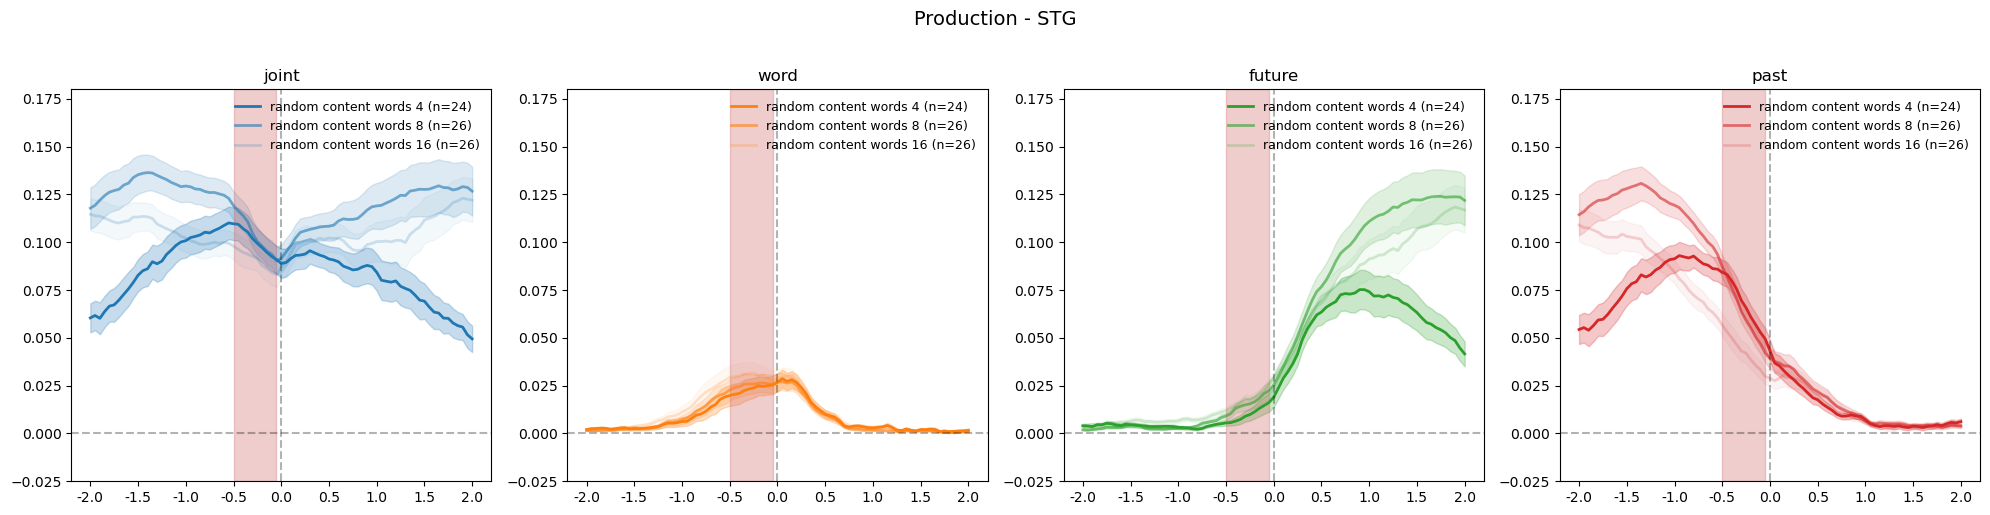

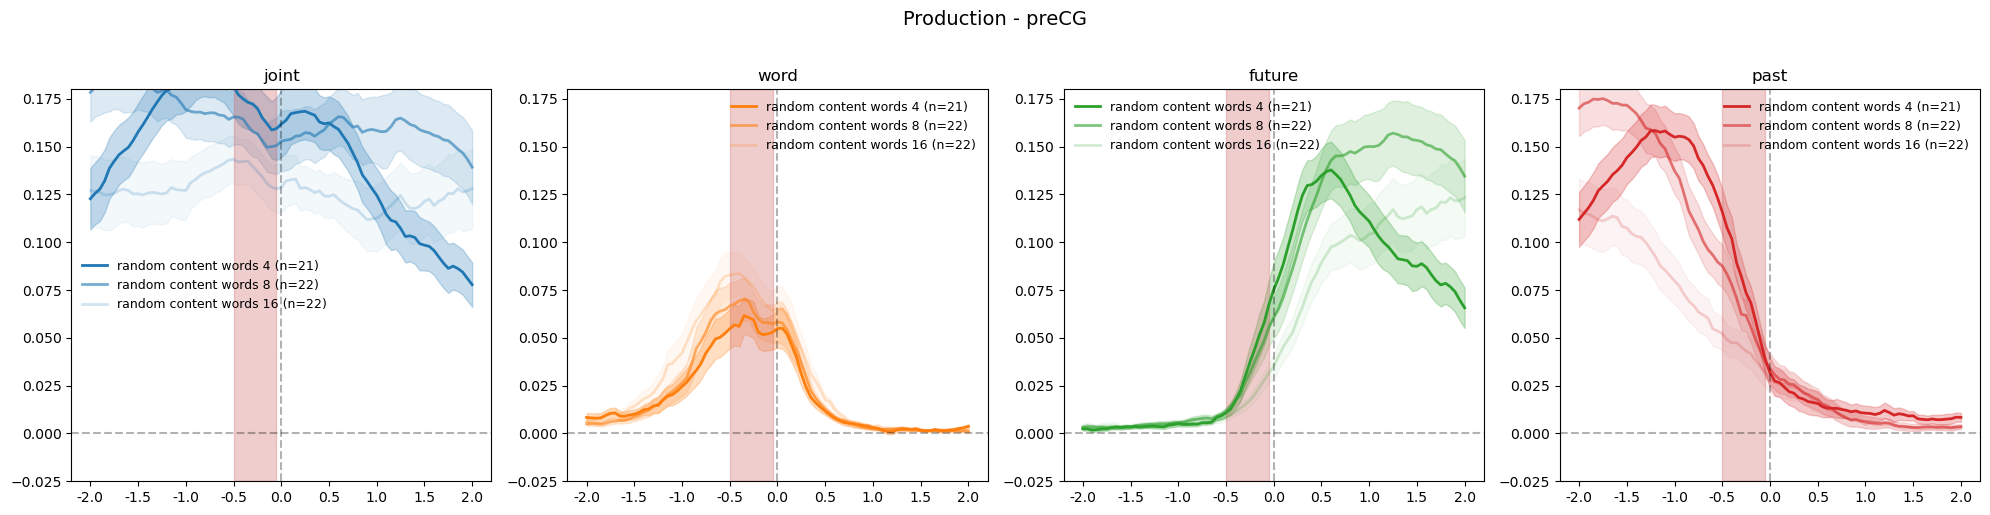

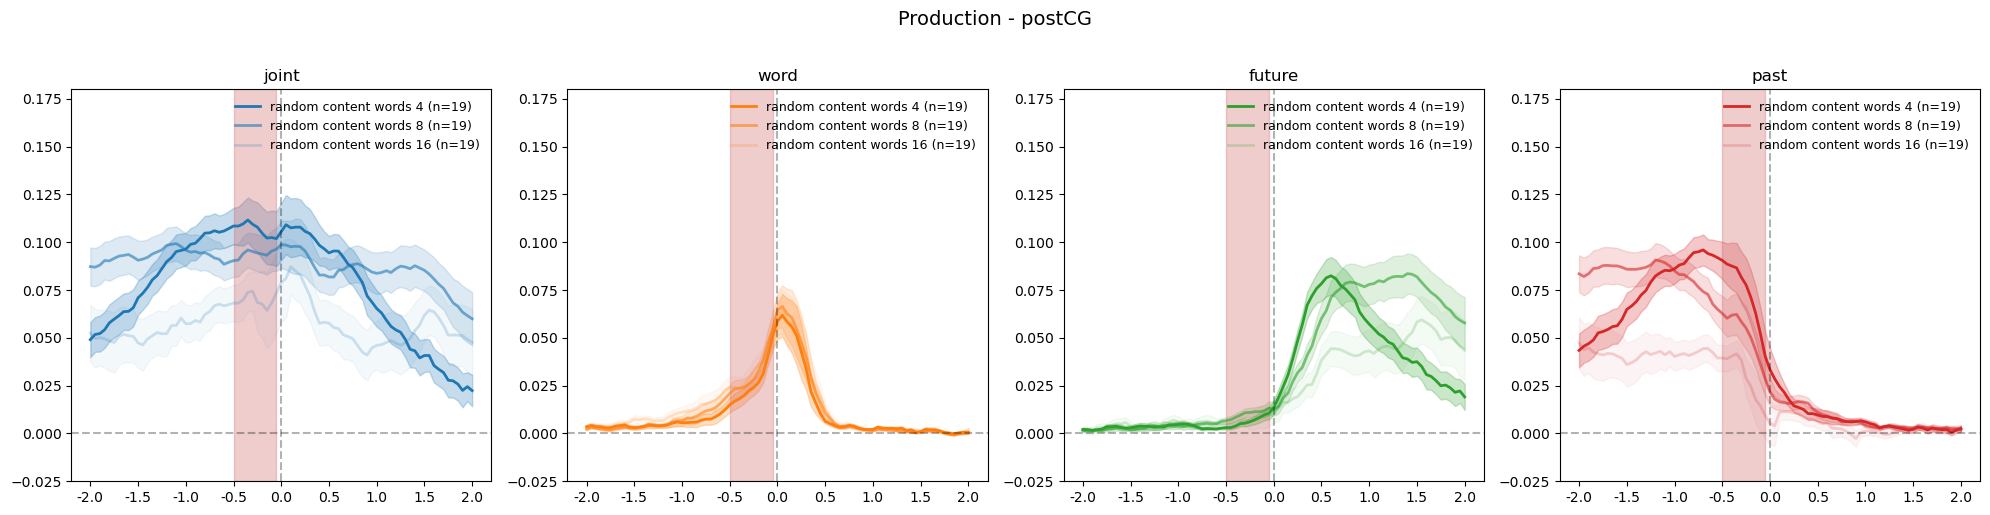

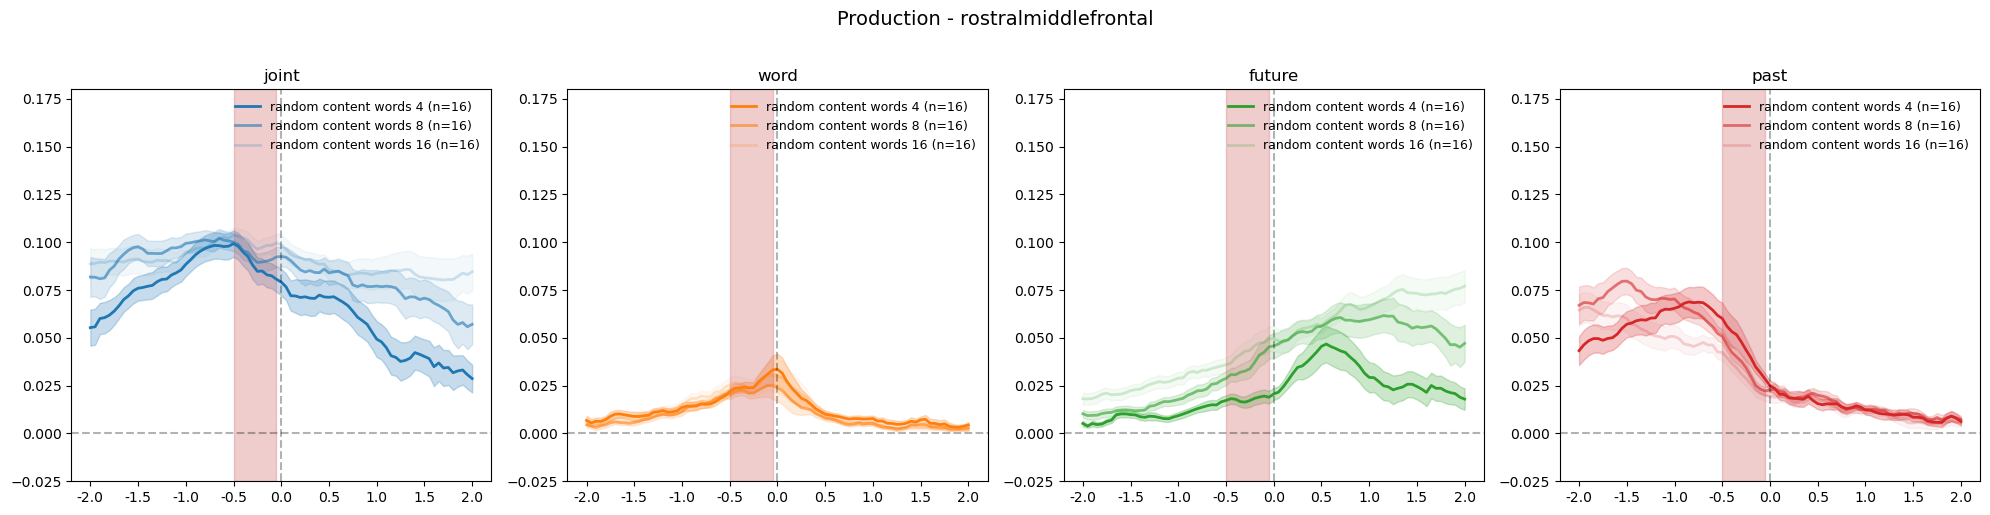

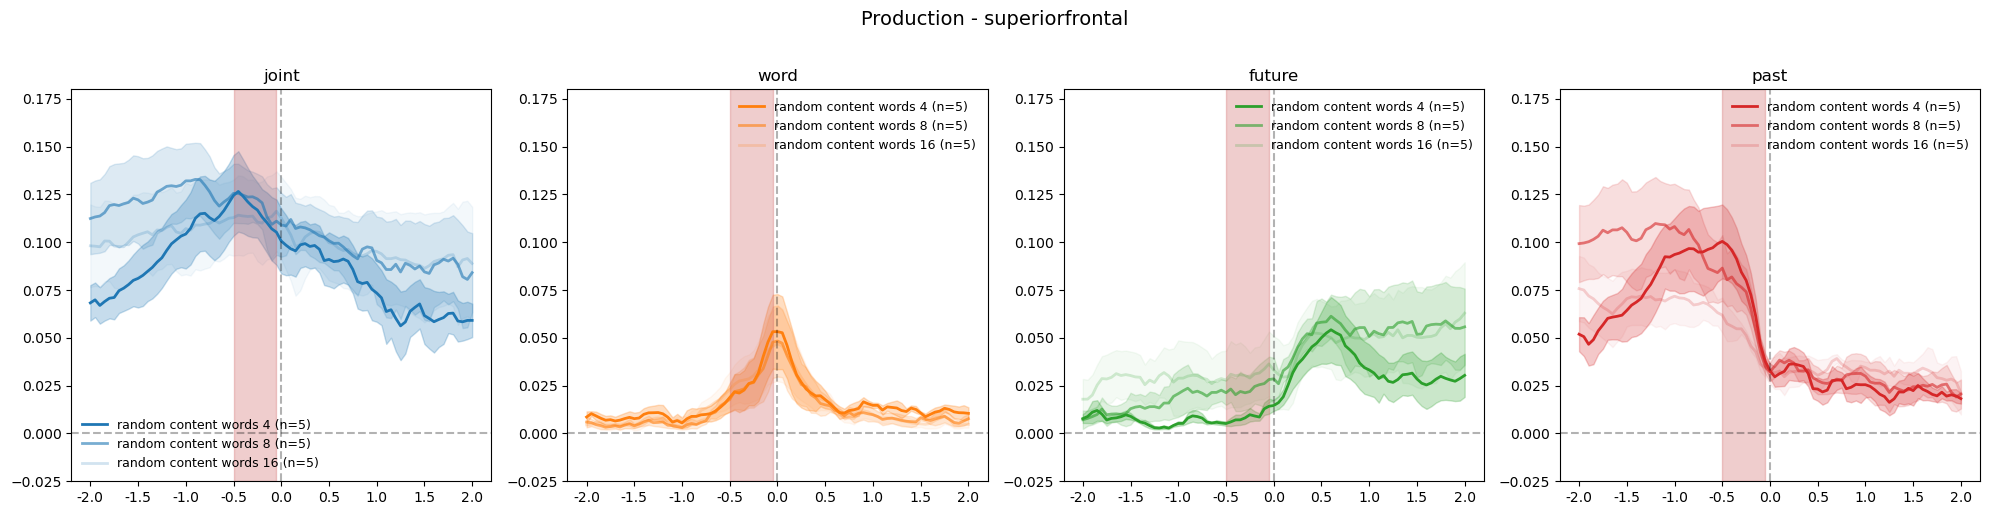

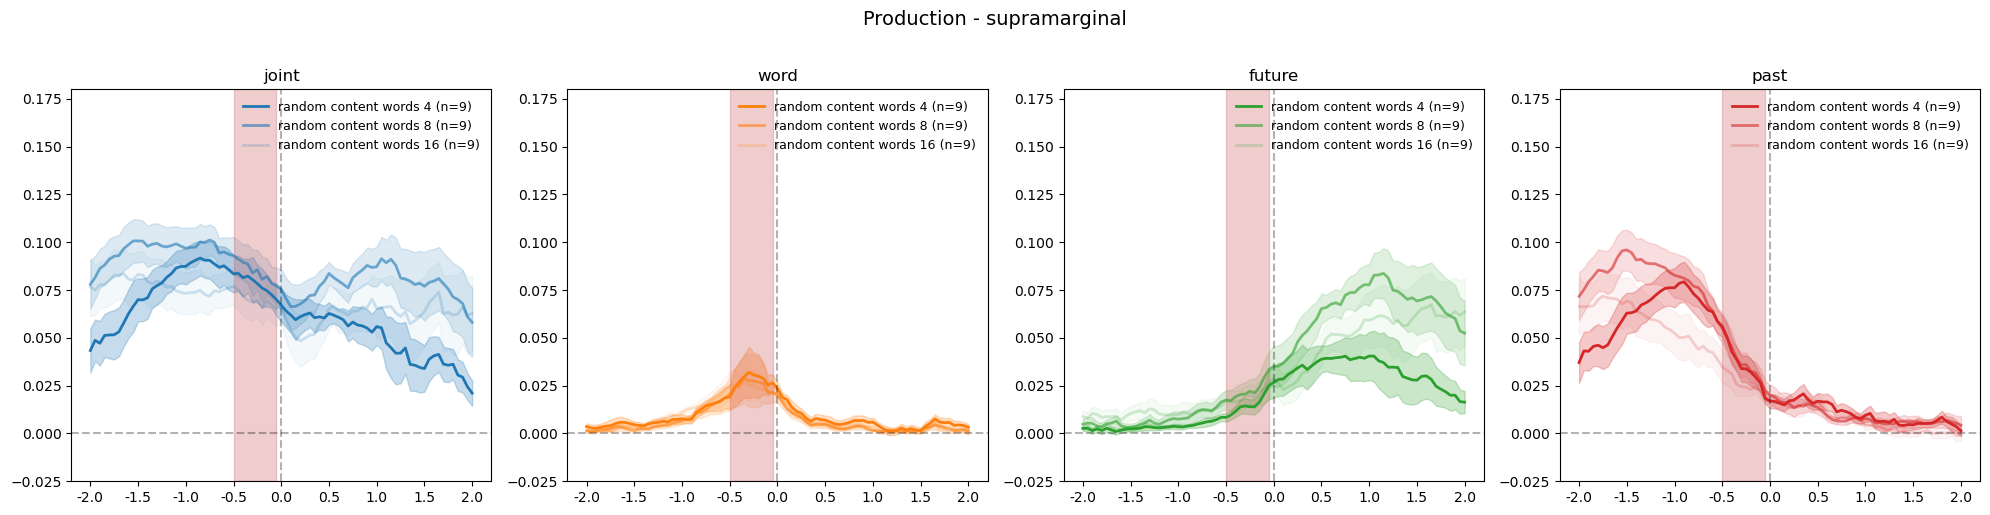

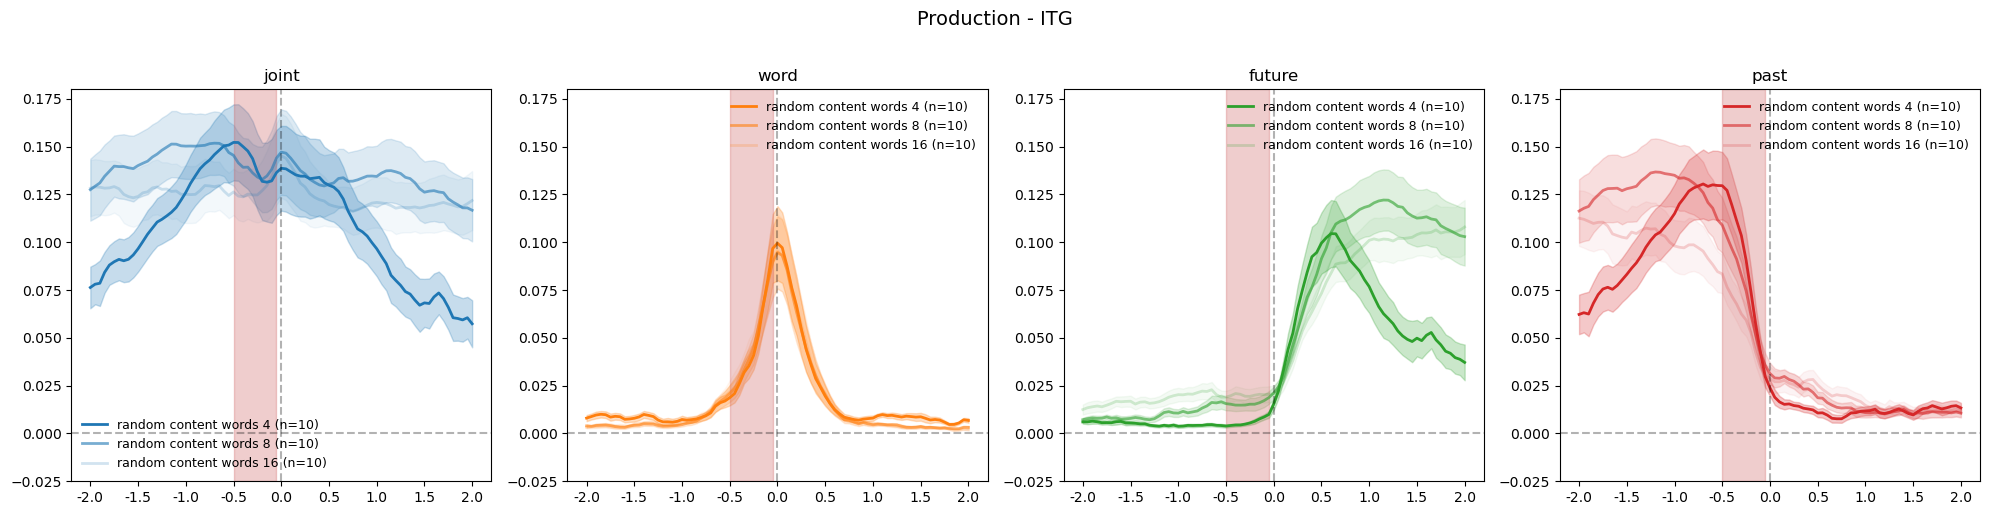

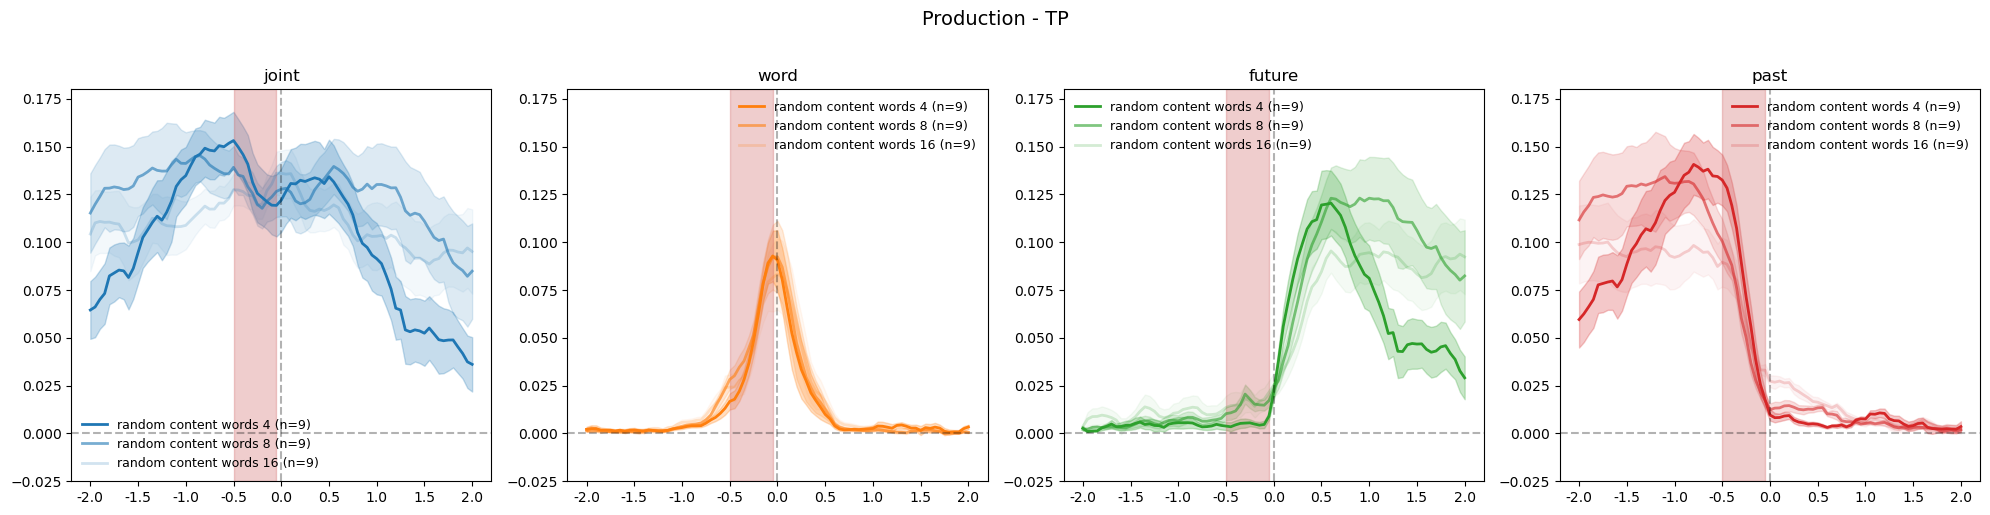

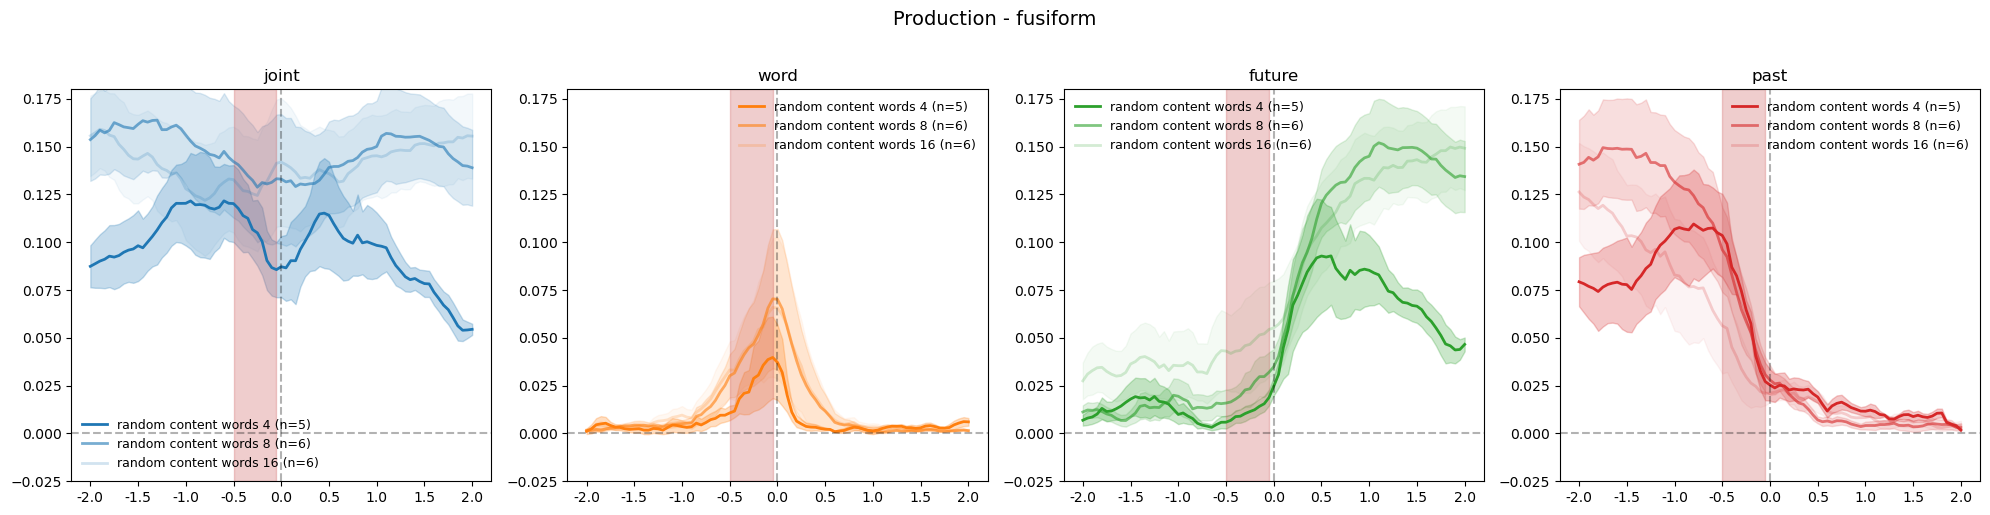

In [14]:
args.lags = {
        "lags_all": np.arange(-2000, 2001, 50),
        "lags_plt": np.arange(-2000, 2001, 50), # selected subset
        "lag_ticks": np.arange(-2000, 2001, 500), # this and next one need to have same number of elements
        "lag_tick_labels": np.arange(-2, 2.001, 0.5), # this and previous one need to have same number of elements
    }


# Process and plot for production DataFrames
rois_to_plot_p = []
for roi in args.rois:
    key = (0, 'joint', roi)
    df = roi_results_p.get(key)
    if df is not None and df.shape[0] > 2:
        rois_to_plot_p.append(roi)

for roi in rois_to_plot_p:
    # Count electrodes
    n_elecs_p = next(
        (len(df) for key, df in roi_results_p.items() 
         if key[2] == roi and isinstance(df, pd.DataFrame) and not df.empty), 
        0
    )
    
    if n_elecs_p < 3:
        continue
    
    pu.plot_all_lines_across_datasets(
        args, 
        roi_results_p, 
        roi, 
        mode="prod", 
        ymax=0.18, 
        save=False, 
        titles=titles
    )

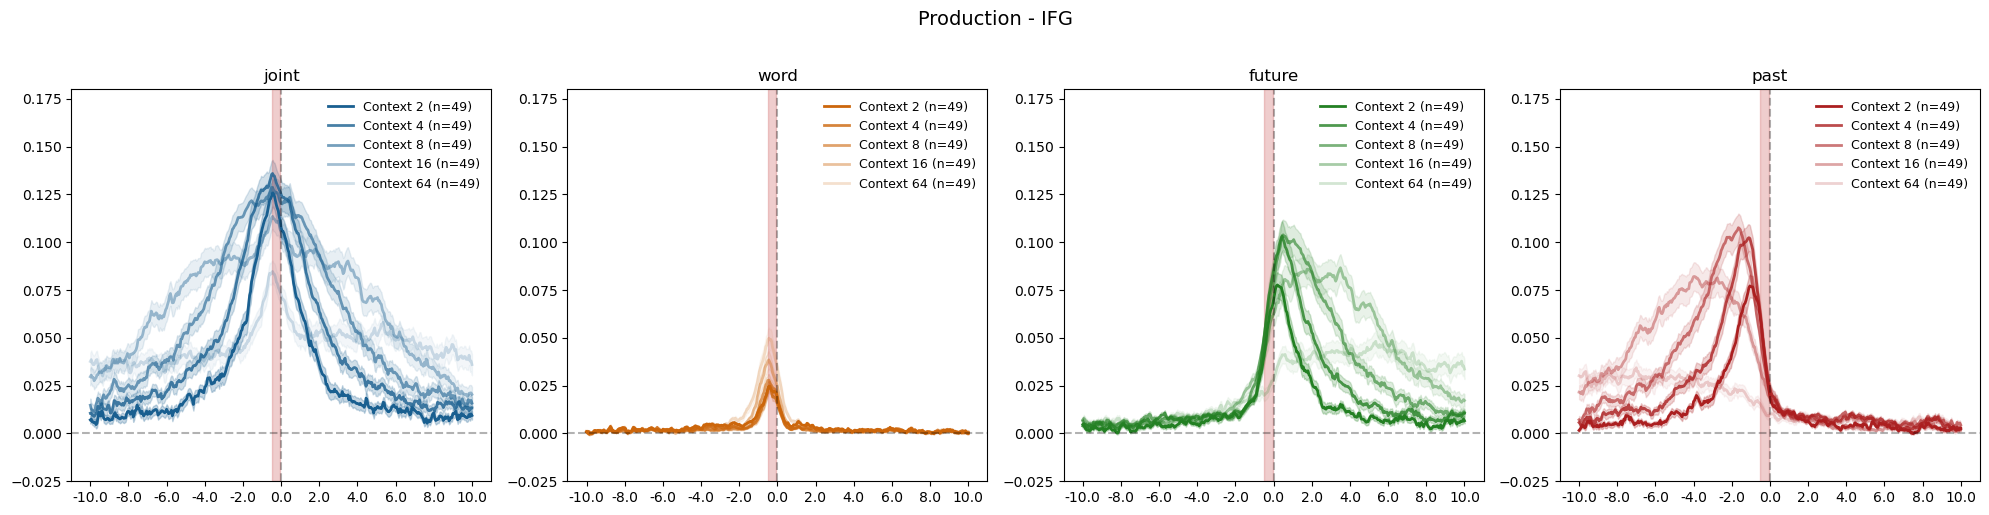

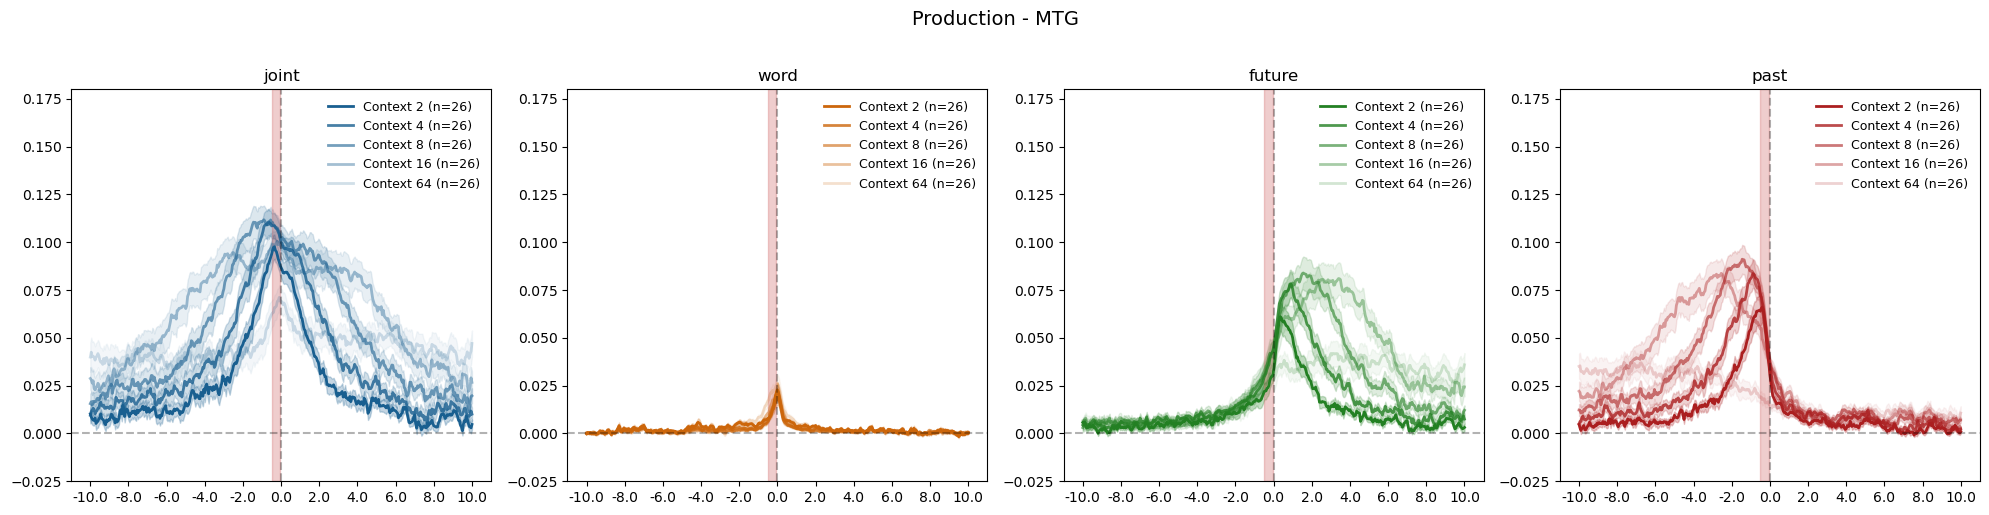

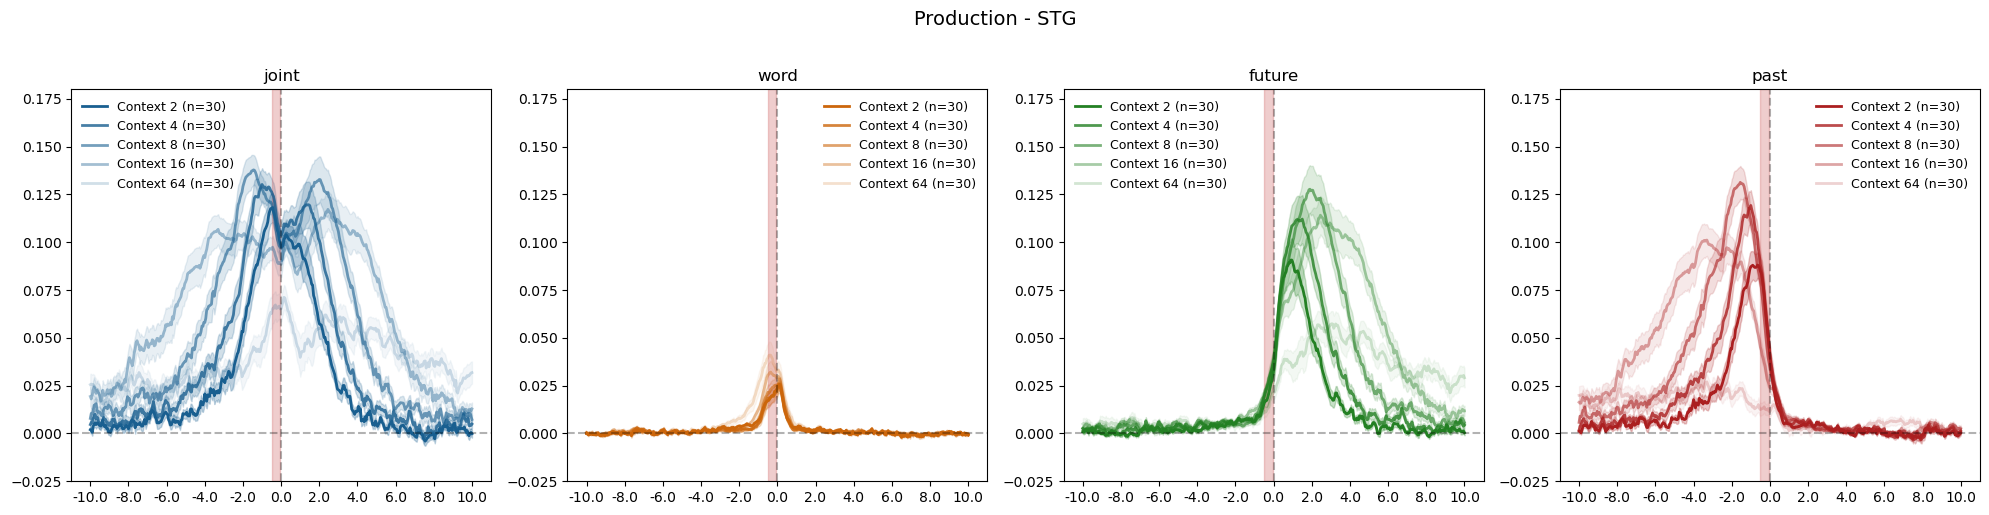

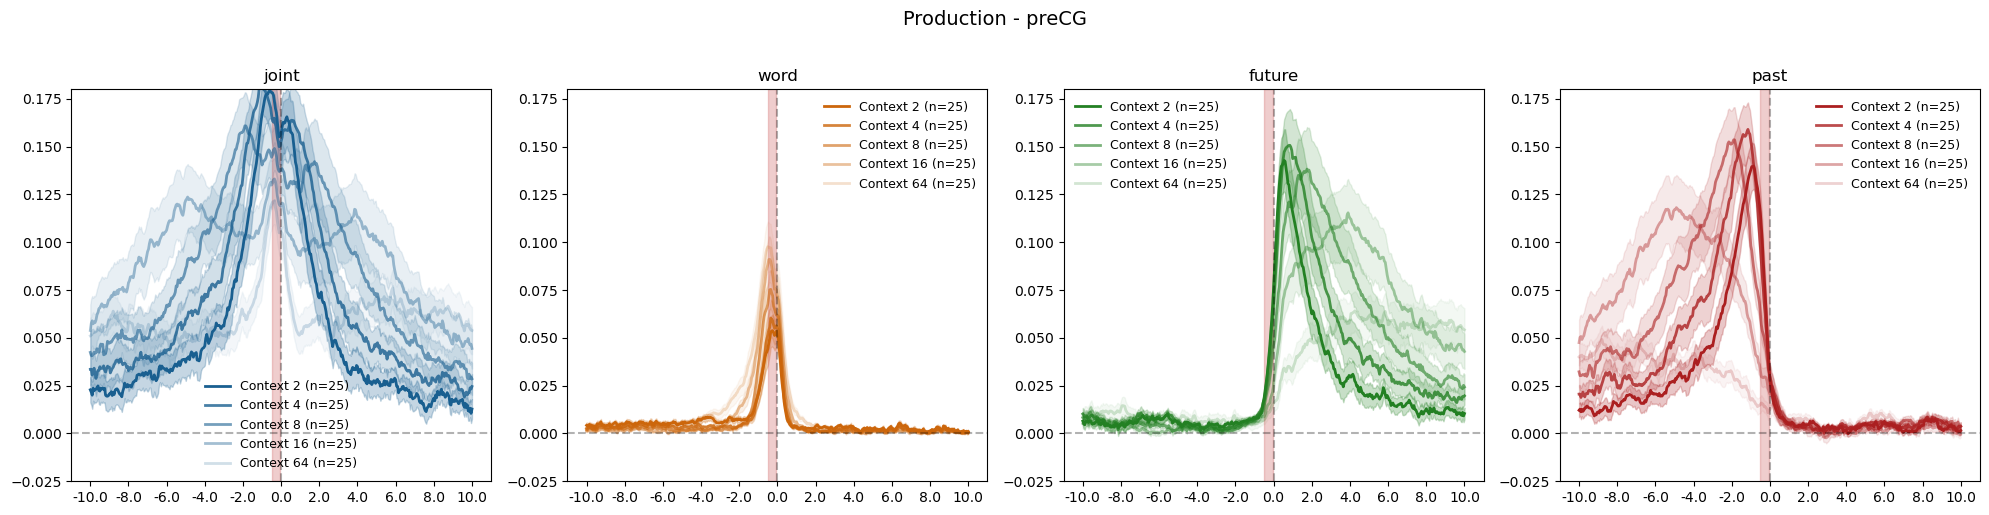

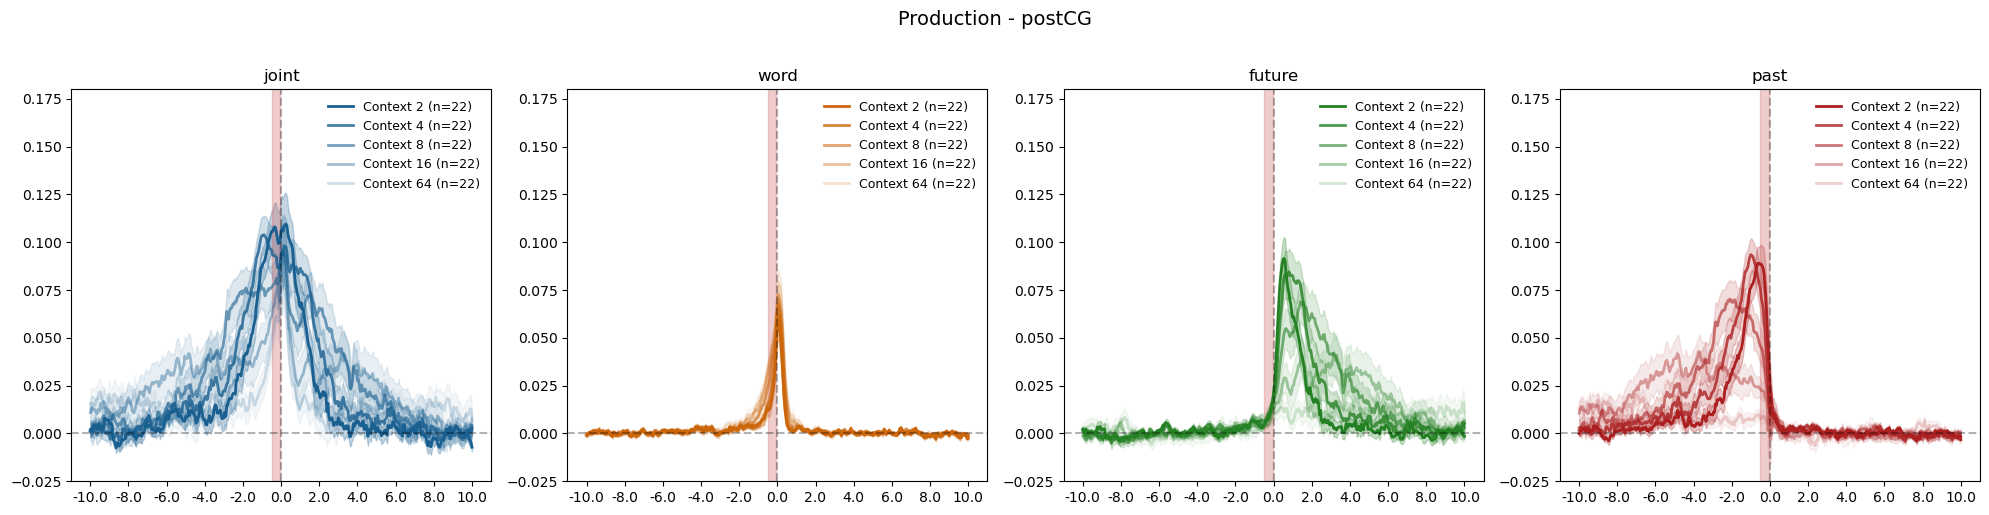

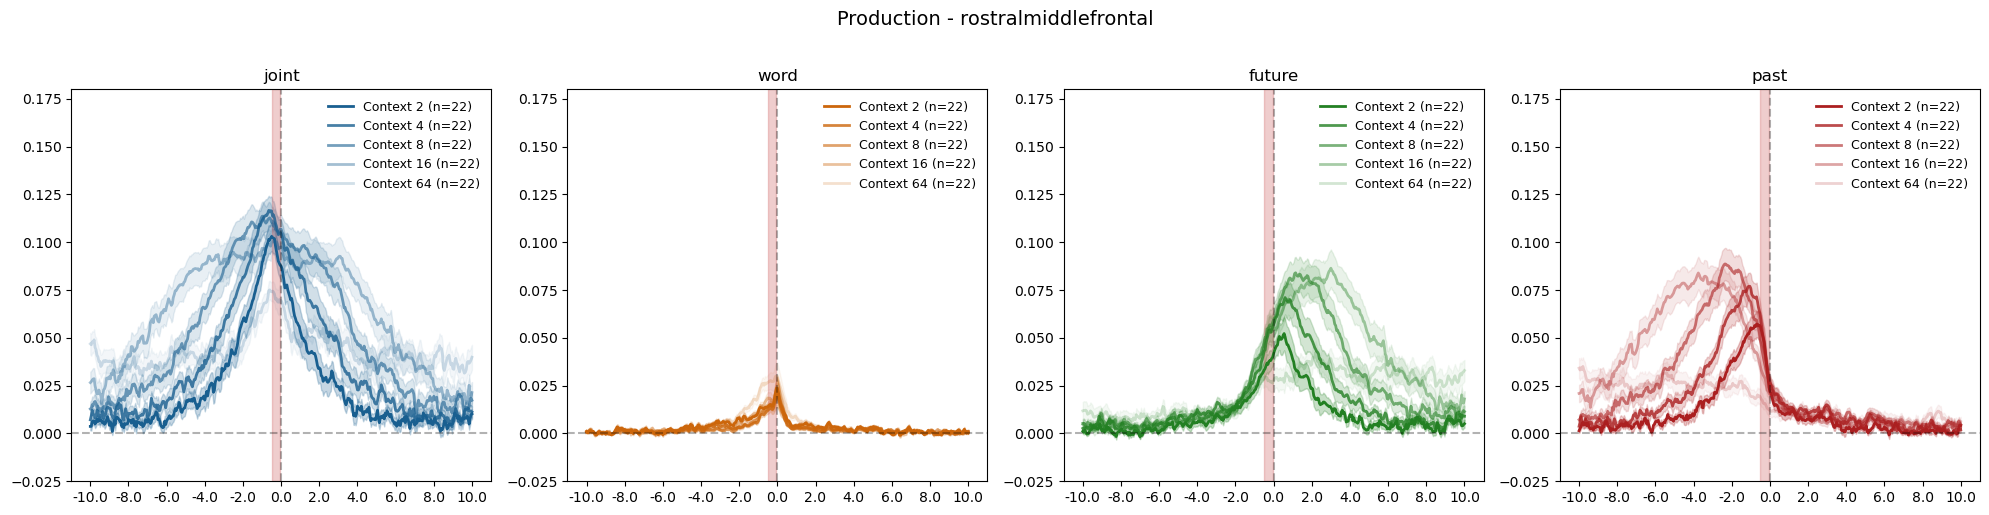

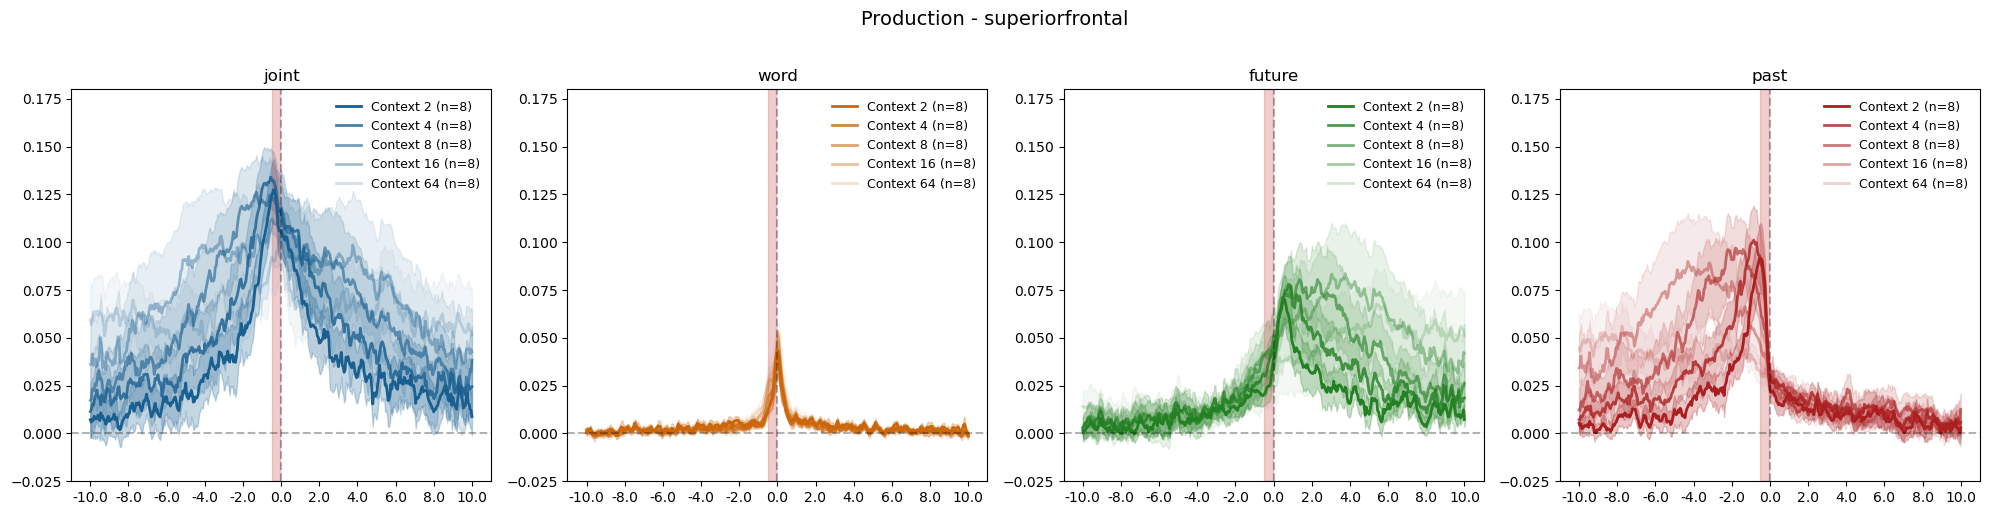

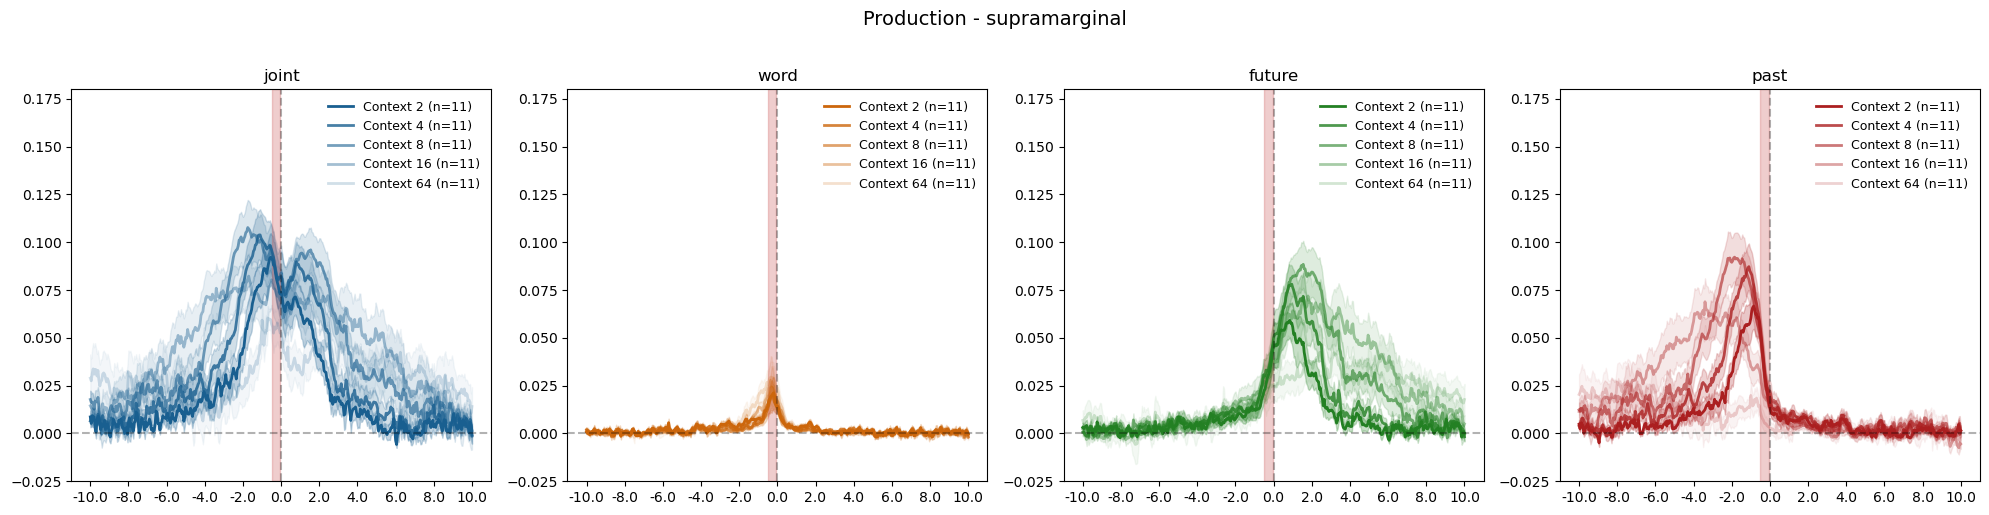

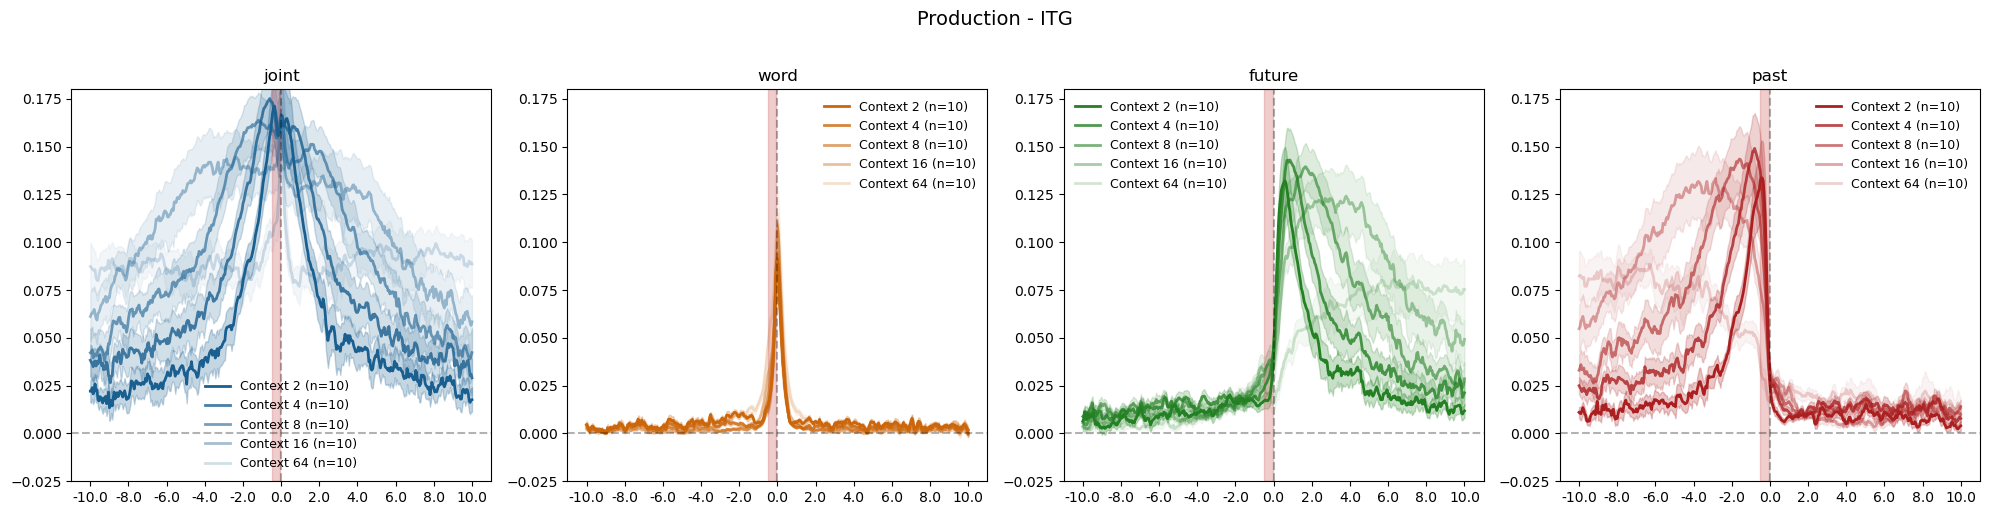

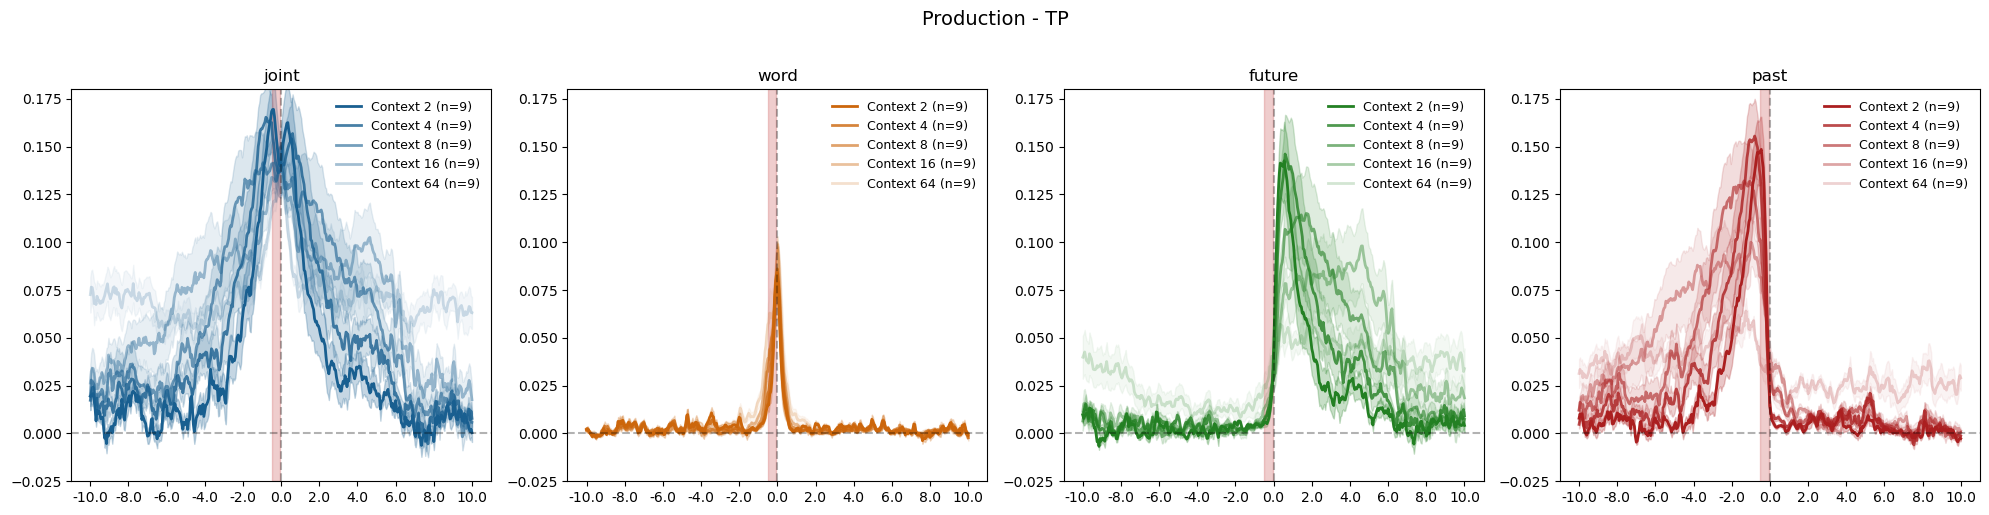

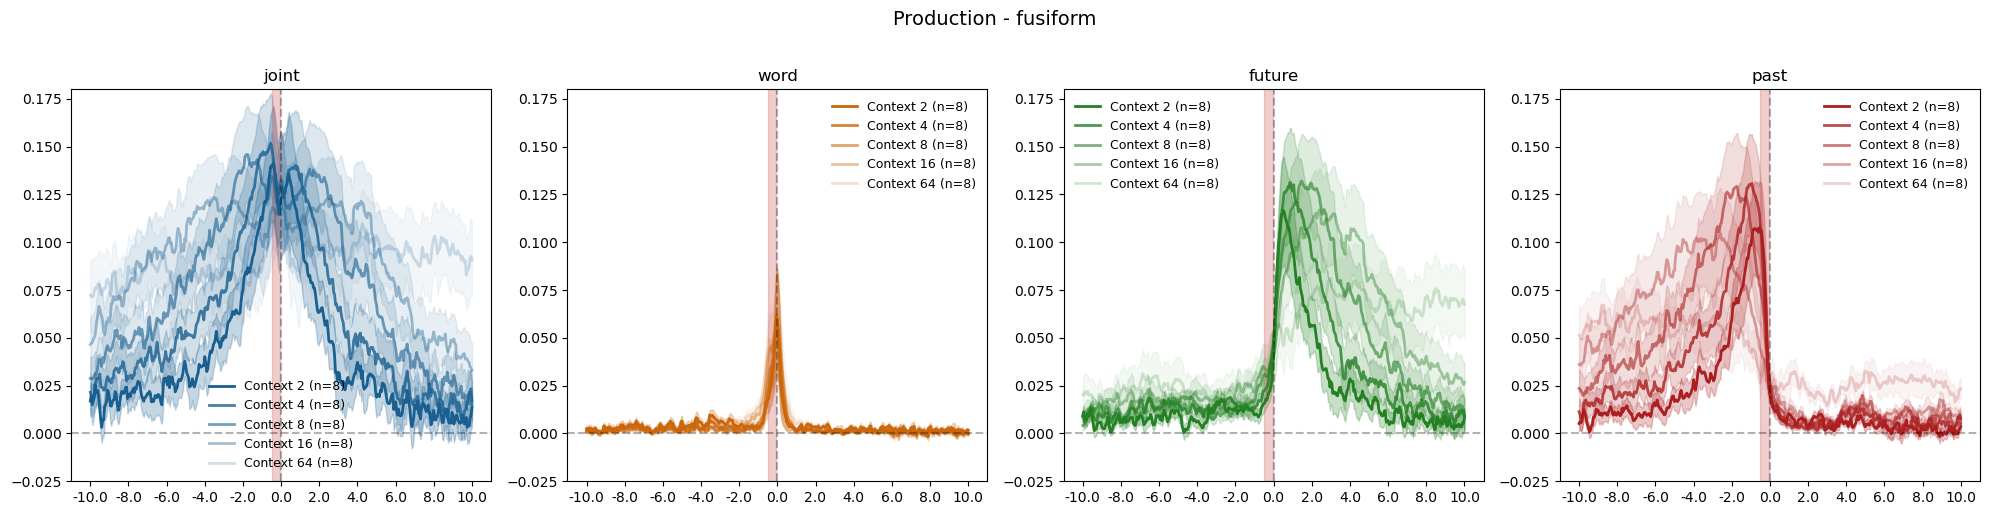

In [ ]:
# Process and plot for comprehension DataFrames
args.lags = {
        "lags_all": np.arange(-2000, 2001, 50),
        "lags_plt": np.arange(-2000, 2001, 50), # selected subset
        "lag_ticks": np.arange(-2000, 2001, 500), # this and next one need to have same number of elements
        "lag_tick_labels": np.arange(-2, 2.001, 0.5), # this and previous one need to have same number of elements
    }

# Process and plot for production DataFrames
rois_to_plot_p = []
for roi in args.rois:
    key = (0, 'joint', roi)
    df = roi_results_p.get(key)
    if df is not None and df.shape[0] > 2:
        rois_to_plot_p.append(roi)

for roi in rois_to_plot_p:
    # Count electrodes
    n_elecs_p = next(
        (len(df) for key, df in roi_results_p.items() 
         if key[2] == roi and isinstance(df, pd.DataFrame) and not df.empty), 
        0
    )
    
    if n_elecs_p < 3:
        continue
    
    pu.plot_all_lines_across_datasets(
        args, 
        roi_results_p, 
        roi, 
        mode="prod", 
        ymax=0.18, 
        save=False, 
        titles=titles
    )

## Calculate Differences Between Context Windows

Calculate maximum differences between context16 and context4/context64 for each electrode.

In [ ]:
# Prepare data for difference calculation
# Rename columns to match lag values for easier processing
lag_cols = np.arange(-60000, 60001, 50)

for df in [context16_c, context16_p, context4_c, context4_p, context64_c, context64_p]:
    n_lag_cols = len(df.columns) - 5
    new_columns = list(lag_cols[:n_lag_cols]) + list(df.columns[-5:])
    df.columns = new_columns

In [ ]:
# Define time windows for each condition
# Comprehension
time_window_future_comp = [col for col in lag_cols if col <= 500]  # <= 0.5s
time_window_past_comp = [col for col in lag_cols if col >= 0]      # >= 0s

# Production  
time_window_future_prod = [col for col in lag_cols if col <= 0]     # <= 0s
time_window_past_prod = [col for col in lag_cols if col >= -500]    # >= -0.5s

# Calculate differences for Context 16 vs Context 4 - Comprehension
diff_sent_comp_c4 = pu.calc_max_diff_percentile(
    context16_c, context4_c, 
    'sentence', time_window_future_comp, percentile=90
)

diff_sent2_comp_c4 = pu.calc_max_diff_percentile(
    context16_c, context4_c,
    'sentence2', time_window_past_comp, percentile=90
)

# Calculate differences for Context 16 vs Context 64 - Comprehension
diff_sent_comp_c64 = pu.calc_max_diff_percentile(
    context16_c, context64_c, 
    'sentence', time_window_future_comp, percentile=90
)

diff_sent2_comp_c64 = pu.calc_max_diff_percentile(
    context16_c, context64_c,
    'sentence2', time_window_past_comp, percentile=90
)

# Calculate differences for Context 16 vs Context 4 - Production
diff_sent_prod_c4 = pu.calc_max_diff_percentile(
    context16_p, context4_p,
    'sentence', time_window_future_prod, percentile=90
)

diff_sent2_prod_c4 = pu.calc_max_diff_percentile(
    context16_p, context4_p,
    'sentence2', time_window_past_prod, percentile=90
)

# Calculate differences for Context 16 vs Context 64 - Production
diff_sent_prod_c64 = pu.calc_max_diff_percentile(
    context16_p, context64_p,
    'sentence', time_window_future_prod, percentile=90
)

diff_sent2_prod_c64 = pu.calc_max_diff_percentile(
    context16_p, context64_p,
    'sentence2', time_window_past_prod, percentile=90
)

## Visualize Differences - Context 16 vs Context 4

In [ ]:
# Plot brain maps for Context 16 vs Context 4
cmap = 'hot'

print("=" * 80)
print("CONTEXT 16 vs CONTEXT 4")
print("=" * 80)

pu.plot_effect_glassbrain(
    diff_sent_comp_c4, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context4 - Comprehension Future (<500ms)'
)

pu.plot_effect_glassbrain(
    diff_sent2_comp_c4, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context4 - Comprehension Past (>0ms)'
)

pu.plot_effect_glassbrain(
    diff_sent_prod_c4, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context4 - Production Future (<0ms)'
)

pu.plot_effect_glassbrain(
    diff_sent2_prod_c4, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context4 - Production Past (>-500ms)'
)

## Visualize Differences - Context 16 vs Context 64

In [ ]:
# Plot brain maps for Context 16 vs Context 64
print("=" * 80)
print("CONTEXT 16 vs CONTEXT 64")
print("=" * 80)

pu.plot_effect_glassbrain(
    diff_sent_comp_c64, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context64 - Comprehension Future (<500ms)'
)

pu.plot_effect_glassbrain(
    diff_sent2_comp_c64, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context64 - Comprehension Past (>0ms)'
)

pu.plot_effect_glassbrain(
    diff_sent_prod_c64, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context64 - Production Future (<0ms)'
)

pu.plot_effect_glassbrain(
    diff_sent2_prod_c64, 
    cmap=cmap, 
    effect_col='max_diff', 
    vmin=0, 
    vmax=0.15, 
    title='Context16 vs Context64 - Production Past (>-500ms)'
)

## Statistical Comparison

In [ ]:
from scipy import stats

print("=" * 80)
print("STATISTICAL COMPARISON: CONTEXT 16 vs CONTEXT 4")
print("=" * 80)

# Comprehension Future
t_stat, p_val = stats.ttest_ind(
    diff_sent_comp_c4['max_diff'].values,
    diff_sent_comp_c64['max_diff'].values
)
print(f"\nComprehension Future: Context4 vs Context64")
print(f"  Mean C4: {diff_sent_comp_c4['max_diff'].mean():.4f}")
print(f"  Mean C64: {diff_sent_comp_c64['max_diff'].mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")

# Comprehension Past
t_stat, p_val = stats.ttest_ind(
    diff_sent2_comp_c4['max_diff'].values,
    diff_sent2_comp_c64['max_diff'].values
)
print(f"\nComprehension Past: Context4 vs Context64")
print(f"  Mean C4: {diff_sent2_comp_c4['max_diff'].mean():.4f}")
print(f"  Mean C64: {diff_sent2_comp_c64['max_diff'].mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")

# Production Future
t_stat, p_val = stats.ttest_ind(
    diff_sent_prod_c4['max_diff'].values,
    diff_sent_prod_c64['max_diff'].values
)
print(f"\nProduction Future: Context4 vs Context64")
print(f"  Mean C4: {diff_sent_prod_c4['max_diff'].mean():.4f}")
print(f"  Mean C64: {diff_sent_prod_c64['max_diff'].mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")

# Production Past
t_stat, p_val = stats.ttest_ind(
    diff_sent2_prod_c4['max_diff'].values,
    diff_sent2_prod_c64['max_diff'].values
)
print(f"\nProduction Past: Context4 vs Context64")
print(f"  Mean C4: {diff_sent2_prod_c4['max_diff'].mean():.4f}")
print(f"  Mean C64: {diff_sent2_prod_c64['max_diff'].mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")

print("\n" + "=" * 80)